# Macro Regime Engine — Portfolio Allocation

This notebook builds a complete macro regime-based asset allocation system:

1. **Growth & Inflation Factors** from FRED economic data
2. **HP-Filter Gaps** for cycle extraction
3. **Deterministic Quadrant Regimes** (High/Low Growth × High/Low Inflation)
4. **Probabilistic GMM Regimes** using Gaussian Mixture Models
5. **ETF Universe Returns** from Yahoo Finance
6. **Regime-Conditional Moments** (means, volatilities, covariances)
7. **Probability-Weighted Portfolio Construction**
8. **Visualization & Analysis**

---

## 1. Import Required Libraries

The user wants to fix a bug in the selected cell. Based on the provided list of installed packages, several libraries imported in this cell (`pandas-datareader`, `scikit-learn`, `statsmodels`, `yfinance`) are missing from the environment. The fix is to add a pip install command to install these missing dependencies.



<llm-snippet-file>C:/Users/james/Dropbox/Python/Economics States/Macro_Regime_Analysis.ipynb</llm-snippet-file>


In [11]:
import os
import numpy as np
import pandas as pd
import datetime as dt
from pandas_datareader import data as pdr
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from statsmodels.tsa.filters.hp_filter import hpfilter
import matplotlib.pyplot as plt
import yfinance as yf

print("✓ All libraries imported successfully")


ModuleNotFoundError: No module named 'sklearn'

## 2. Configuration Parameters

In [51]:
# FRED API settings
FRED_START = "1994-01-01"  # Start earlier to get regimes from 1995 (need 12 months for YoY inflation)
FRED_END   = dt.date.today().strftime("%Y-%m-%d")
FRED_API   = os.getenv("FRED_API_KEY", None)

# ---------------------------------------------------------------------------
# COVID handling
# ---------------------------------------------------------------------------
# April 2020 sits at -15.2 sigma in the growth factor; the next largest
# non-COVID deviation is +3.4. Because every standardization here uses the
# full-sample sd, leaving COVID in inflates sd by roughly 2x and compresses all
# normal-times variation toward zero -- which is what collapsed 353 of 376
# months into a single "Goldilocks" blob and spent an entire GMM component on
# one month.
#
# These months are excluded from ESTIMATION ONLY (standardization moments, PCA
# loadings, HP-cycle scaling, GMM fit). They are still transformed, still
# classified, and still appear in every output -- they simply do not get to
# define what "normal" looks like.
COVID_EXCLUDE = ("2020-03-01", "2020-12-01")   # set to None to disable


def estimation_mask(index, exclude=None):
    """Boolean mask over `index`, False inside the excluded window."""
    exclude = COVID_EXCLUDE if exclude is None else exclude
    if not exclude:
        return pd.Series(True, index=index)
    lo, hi = pd.Timestamp(exclude[0]), pd.Timestamp(exclude[1])
    return pd.Series(~((index >= lo) & (index <= hi)), index=index)


def _standardize(df_or_s, mask):
    """Standardize using moments from `mask` rows only, applied to all rows."""
    ref = df_or_s[mask]
    return (df_or_s - ref.mean()) / ref.std(ddof=0)

# HP Filter parameter (monthly data)
HP_LAMBDA_M = 129600

# ---------------------------------------------------------------------------
# Quadrant classification thresholds (in standard deviations)
# ---------------------------------------------------------------------------
# THETA_G / THETA_PI are the MEMORYLESS thresholds. With both at 0.0 the
# classifier has no deadband at all, so an observation sitting near the origin
# flips quadrant on pure noise -- which is why average regime duration was
# 1.7-2.1 months. Macro regimes that change every other month are not regimes.
THETA_G  = 0.0
THETA_PI = 0.0

# HYSTERESIS_THETA adds inertia instead of a deadband. Each axis becomes a
# Schmitt trigger: once growth is classified "high" it stays high until the gap
# falls BELOW -theta, and vice versa. This keeps exactly four states (no
# "Neutral" bucket leaking into the taxonomy) while removing boundary chatter.
#
# Deliberately NOT a minimum-duration / run-merging rule: those decide the
# regime at time t using data from t+1 onward, which would add look-ahead to a
# pipeline that already has too much. Hysteresis is causal -- the state at t
# depends only on observations up to t.
#
# Set to 0.0 to recover the original memoryless behaviour. See the sensitivity
# table printed in Section 8 for how duration responds to this parameter.
HYSTERESIS_THETA = 0.50   # base case: ~4.6-month average regime duration

# ETF universe
#
# Inception dates below are the actual Yahoo first-trade dates. An earlier
# version of this config dropped TLT/LQD/HYG as "limited history (starts 2014)",
# which was wrong -- TLT and LQD are the LONGEST-history bond ETFs here (2002).
# The asset actually truncating the sample was PDBC (Nov 2014). Replacing it
# with DBC (Feb 2006, broad commodity index) moves the binding constraint to
# VEA (Jul 2007) and lets the three credit/duration sleeves come back for free.
#
# Common-history sample: 2007-07 onward (~19 yrs), which now spans the 2008-09
# recession and the 2021-22 inflation spike. The previous PDBC-bound sample
# began 2014-11 and contained NO recession, which is why the Recession regime
# had a single observation.
YAHOO_TICKERS = {
    "SPY":  "Equity_US",                # 1993-01
    "VEA":  "Equity_DevelopedExUS",     # 2007-07  <-- binding constraint
    "EEM":  "Equity_EM",                # 2003-04
    "AGG":  "US_Aggregate_Bonds",       # 2003-09
    "TLT":  "US_Long_Treasury",         # 2002-07
    "LQD":  "Corp_IG",                  # 2002-07
    "HYG":  "Corp_HY",                  # 2007-04
    "VNQ":  "REITs",                    # 2004-09
    "GLD":  "Gold",                     # 2004-11
    "DBC":  "Commodities",              # 2006-02  (was PDBC, 2014-11)
    "TIP":  "TIPS",                     # 2003-12
}

# Real activity indicators for growth factor
REAL_ACTIVITY_SERIES = {
    "INDPRO":  "INDPRO",      # Industrial Production
    "PAYEMS":  "PAYEMS",      # Nonfarm Payrolls
    "UNRATE":  "UNRATE",      # Unemployment Rate
    "RETAIL":  "RRSFS",       # Retail Sales
    "HOUST":   "HOUST"        # Housing Starts
}

# Price indicators for inflation factor
#
# ULC (ULCNFB) is a QUARTERLY series. Because transform_prices() ends with
# .dropna(), including it silently collapsed the entire price panel to
# quarter-months: real_std was (387, 5) but price_std was only (75, 5), so the
# whole "monthly" regime pipeline was really quarterly and threw away 2/3 of
# the return data. Set INCLUDE_ULC = True to restore the old behaviour.
INCLUDE_ULC = False

# WAGES is spliced. CES0500000003 (all employees) only starts 2006-03, and with
# the 12-month YoY transform that alone set the sample start at 2007-04.
# AHETPI (production & nonsupervisory employees) runs from 1964 and tracks it
# closely in growth terms (mean YoY diff -0.21pp, sd 0.41pp), so it back-fills
# the history. List order is [oldest, ..., newest] -- see download_fred().
#
# NOTE the two series differ in LEVEL by ~21% at the 2006-03 join, so they are
# ratio-linked, not naively fillna'd. A naive splice would inject a spurious
# +21pp YoY inflation spike lasting 12 months.
PRICE_SERIES = {
    "CPI":      "CPIAUCSL",                     # Consumer Price Index
    "CPI_CORE": "CPILFESL",                     # Core CPI
    "PPI":      "PPIACO",                       # Producer Price Index
    "WAGES":    ["AHETPI", "CES0500000003"],    # Avg hourly earnings (spliced)
}

if INCLUDE_ULC:
    PRICE_SERIES["ULC"] = "ULCNFB"              # Unit Labor Costs (QUARTERLY)

print(f"Date range: {FRED_START} to {FRED_END}")
print(f"FRED API Key set: {FRED_API is not None}")

Date range: 1994-01-01 to 2025-11-16
FRED API Key set: False


## 3. Define Helper Functions - FRED Download & Transformation

In [3]:
import warnings


def _ratio_link(series_list):
    """
    Chain-link a list of overlapping level series into one continuous series.

    Input order is [oldest, ..., newest]. Each older series is rescaled by the
    ratio of the two series at their first common observation, so the JOIN is
    level-continuous and the older series contributes only its growth rates.

    The previous implementation simply fillna'd the older series in at its raw
    level. For AHETPI -> CES0500000003 those levels differ by ~21% at 2006-03,
    which after the 12-month log difference in transform_prices() would appear
    as a fabricated +21pp inflation spike persisting for a year.
    """
    linked = series_list[-1].copy()
    for older in reversed(series_list[:-1]):
        overlap = pd.concat([older, linked], axis=1).dropna()
        if len(overlap) == 0:
            # No overlap -> cannot rescale; fall back to raw fill and warn.
            warnings.warn(
                f"No overlap between spliced segments; joining at raw levels, "
                f"which may introduce a discontinuity.",
                RuntimeWarning, stacklevel=3,
            )
            linked = linked.combine_first(older)
            continue
        join_date = overlap.index[0]
        factor = overlap.iloc[0, 1] / overlap.iloc[0, 0]   # newer / older
        linked = linked.combine_first(older * factor)
        print(f"    spliced at {join_date.strftime('%Y-%m')} "
              f"(scale factor {factor:.4f} applied to earlier segment)")
    return linked


def download_fred(series_dict, start=FRED_START, end=FRED_END, api_key=FRED_API):
    """Download multiple series from FRED, with support for ratio-linked splicing.

    A value given as a LIST is treated as a splice specification, ordered
    [oldest, ..., newest], and chain-linked via _ratio_link().
    """
    df = pd.DataFrame()

    def _fetch(code):
        if api_key:
            return pdr.DataReader(code, "fred", start, end, api_key=api_key)
        return pdr.DataReader(code, "fred", start, end)

    for name, code in series_dict.items():
        if isinstance(code, list):
            print(f"  {name}: splicing {' <- '.join(code)}")
            series_list = [_fetch(c).iloc[:, 0] for c in code]
            spliced = _ratio_link(series_list)
            spliced.name = name
            df = df.join(pd.DataFrame(spliced), how="outer")
        else:
            s = _fetch(code)
            s.columns = [name]
            df = df.join(s, how="outer")
    return df


def transform_real(df):
    """
    Transform real activity indicators:
    - Log differences (% m/m) for IP, payrolls, retail, housing
    - UNRATE kept in levels
    - Standardize all series
    """
    df = df.copy()
    for col in ["INDPRO", "PAYEMS", "RETAIL", "HOUST"]:
        df[col] = np.log(df[col]).diff() * 100
    df = df.dropna()
    # Standardize on non-COVID moments; COVID rows are still returned.
    return _standardize(df, estimation_mask(df.index))


def transform_prices(df):
    """
    Transform price indicators:
    - YoY inflation (12-month log difference)
    - Standardize all series
    """
    df = df.copy()
    for col in df.columns:
        df[col] = (np.log(df[col]) - np.log(df[col].shift(12))) * 100
    df = df.dropna()
    # Standardize on non-COVID moments; COVID rows are still returned.
    return _standardize(df, estimation_mask(df.index))

print("✓ FRED functions defined")

✓ FRED functions defined


## 4. Download FRED Data

This cell downloads economic data from FRED. **Run this first** to test your API connection.

In [4]:
# Download real activity data
print("Downloading real activity series from FRED...")
real_raw = download_fred(REAL_ACTIVITY_SERIES)
print(f"✓ Real activity data: {real_raw.shape[0]} observations, {real_raw.shape[1]} series")
print(f"  Date range: {real_raw.index[0]} to {real_raw.index[-1]}")

# Download price data
print("\nDownloading price series from FRED...")
price_raw = download_fred(PRICE_SERIES)
print(f"✓ Price data: {price_raw.shape[0]} observations, {price_raw.shape[1]} series")
print(f"  Date range: {price_raw.index[0]} to {price_raw.index[-1]}")

# Preview the data
print("\n--- Real Activity Data (last 5 rows) ---")
display(real_raw.tail())

print("\n--- Price Data (last 5 rows) ---")
display(price_raw.tail())

✓ Real activity data: 380 observations, 5 series
  Date range: 1994-01-01 00:00:00 to 2025-08-01 00:00:00

✓ Real activity data: 380 observations, 5 series
  Date range: 1994-01-01 00:00:00 to 2025-08-01 00:00:00

✓ Price data: 381 observations, 5 series
  Date range: 1994-01-01 00:00:00 to 2025-09-01 00:00:00

--- Real Activity Data (last 5 rows) ---
✓ Price data: 381 observations, 5 series
  Date range: 1994-01-01 00:00:00 to 2025-09-01 00:00:00

--- Real Activity Data (last 5 rows) ---


,INDPRO,PAYEMS,UNRATE,RETAIL,HOUST
DATE,,,,,
2025-04-01,103.6224,159433,4.2,225333,1398
2025-05-01,103.6570,159452,4.2,223377,1282
2025-06-01,104.2115,159439,4.1,224894,1382
2025-07-01,103.8194,159518,4.2,225812,1429
2025-08-01,103.9203,159540,4.3,226373,1307



--- Price Data (last 5 rows) ---


,CPI,CPI_CORE,PPI,WAGES,ULC
DATE,,,,,
2025-05-01,320.580,326.854,258.642,36.23,NaN
2025-06-01,321.500,327.600,260.690,36.31,NaN
2025-07-01,322.132,328.656,262.562,36.43,NaN
2025-08-01,323.364,329.793,262.443,36.53,NaN
2025-09-01,324.368,330.542,NaN,NaN,NaN


In [5]:
# Check the WAGES splice around the transition point (2006)
print("\nWAGES series splice check (around 2006 transition):")
print(price_raw['WAGES'].loc['2005-01-01':'2007-12-01'])


WAGES series splice check (around 2006 transition):
DATE
2005-01-01      NaN
2005-02-01      NaN
2005-03-01      NaN
2005-04-01      NaN
2005-05-01      NaN
2005-06-01      NaN
2005-07-01      NaN
2005-08-01      NaN
2005-09-01      NaN
2005-10-01      NaN
2005-11-01      NaN
2005-12-01      NaN
2006-01-01      NaN
2006-02-01      NaN
2006-03-01    20.05
2006-04-01    20.15
2006-05-01    20.13
2006-06-01    20.23
2006-07-01    20.29
2006-08-01    20.32
2006-09-01    20.40
2006-10-01    20.42
2006-11-01    20.49
2006-12-01    20.58
2007-01-01    20.59
2007-02-01    20.68
2007-03-01    20.73
2007-04-01    20.77
2007-05-01    20.84
2007-06-01    20.95
2007-07-01    20.94
2007-08-01    21.00
2007-09-01    21.04
2007-10-01    21.07
2007-11-01    21.12
2007-12-01    21.16
Name: WAGES, dtype: float64


## 5. Transform Economic Data

In [6]:
# Transform real activity (growth rates)
real_std = transform_real(real_raw)
print(f"Real activity (standardized): {real_std.shape}")

# Transform prices (inflation rates)
price_std = transform_prices(price_raw)
print(f"Price data (standardized): {price_std.shape}")

# Align indices
idx = real_std.index.intersection(price_std.index)
real_std = real_std.loc[idx]
price_std = price_std.loc[idx]

print(f"\nAligned data: {len(idx)} common observations")
print(f"Date range: {idx[0]} to {idx[-1]}")

Real activity (standardized): (379, 5)
Price data (standardized): (73, 5)

Aligned data: 73 common observations
Date range: 2007-04-01 00:00:00 to 2025-04-01 00:00:00


In [8]:
# Check what's limiting the price data
print("Price series availability:")
for col in price_raw.columns:
    first_valid = price_raw[col].first_valid_index()
    last_valid = price_raw[col].last_valid_index()
    n_valid = price_raw[col].notna().sum()
    print(f"  {col:12s}: {first_valid} to {last_valid} ({n_valid} obs)")

Price series availability:
  CPI         : 1994-01-01 00:00:00 to 2025-09-01 00:00:00 (381 obs)
  CPI_CORE    : 1994-01-01 00:00:00 to 2025-09-01 00:00:00 (381 obs)
  PPI         : 1994-01-01 00:00:00 to 2025-08-01 00:00:00 (380 obs)
  WAGES       : 2006-03-01 00:00:00 to 2025-08-01 00:00:00 (234 obs)
  ULC         : 1994-01-01 00:00:00 to 2025-04-01 00:00:00 (126 obs)


## 6. Extract Growth and Inflation Factors (PCA)

Growth Factor - Variance explained: 75.59%
Inflation Factor - Variance explained: 62.11%


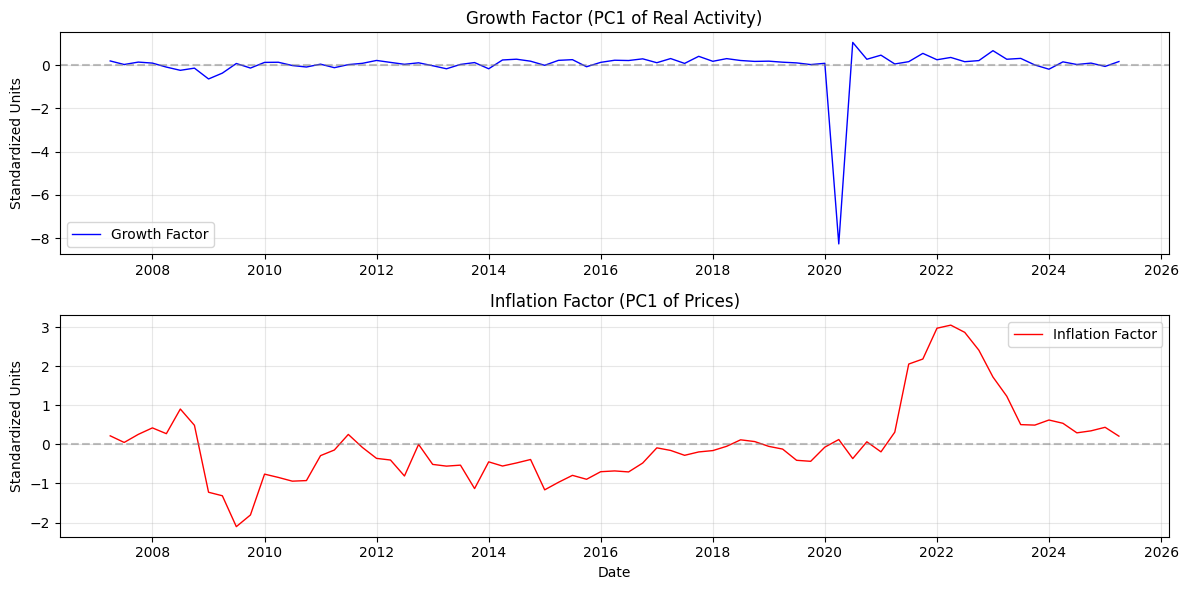


PCA COMPONENT WEIGHTS

GROWTH FACTOR:
  INDPRO              :  0.5411
  PAYEMS              :  0.7119
  UNRATE              : -0.2094
  RETAIL              :  0.3451
  HOUST               :  0.1935
  Variance Explained  :  75.59%

INFLATION FACTOR:
  CPI                 :  0.5337
  CPI_CORE            :  0.4907
  PPI                 :  0.3970
  WAGES               :  0.3600
  ULC                 :  0.4327
  Variance Explained  :  62.11%


In [9]:
def extract_pc(df_std, sign_ref=None):
    """
    Extract the first principal component.

    Loadings are FIT on non-COVID months only, then applied to every month, so
    a single 2020 observation cannot define the factor's direction or scale.

    `sign_ref` pins the component's orientation: PCA sign is arbitrary, so
    without this the "Growth Factor" can silently invert between runs on
    revised data and flip every regime label. The component is oriented to
    correlate POSITIVELY with the named column.
    """
    X = df_std.dropna()
    m = estimation_mask(X.index)

    pca = PCA(n_components=1)
    pca.fit(X[m])                              # loadings: non-COVID only
    pc1 = pd.Series(pca.transform(X)[:, 0], index=X.index)   # applied to all

    if sign_ref is not None and sign_ref in X.columns:
        if np.corrcoef(pc1[m], X.loc[m, sign_ref])[0, 1] < 0:
            pc1 = -pc1
            pca.components_ = -pca.components_

    return _standardize(pc1, m), pca

# Extract growth factor
gf, pca_g = extract_pc(real_std, sign_ref="INDPRO")   # + = expansion
gf.name = "GrowthFactor"
print(f"Growth Factor - Variance explained: {pca_g.explained_variance_ratio_[0]:.2%}")

# Extract inflation factor
pf, pca_p = extract_pc(price_std, sign_ref="CPI")     # + = rising prices
pf.name = "InflationFactor"
print(f"Inflation Factor - Variance explained: {pca_p.explained_variance_ratio_[0]:.2%}")

# Plot factors
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(gf.index, gf.values, label="Growth Factor", color='blue', linewidth=1)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.set_title("Growth Factor (PC1 of Real Activity)")
ax1.set_ylabel("Standardized Units")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(pf.index, pf.values, label="Inflation Factor", color='red', linewidth=1)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.set_title("Inflation Factor (PC1 of Prices)")
ax2.set_ylabel("Standardized Units")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Display PCA component weights
print("\n" + "="*70)
print("PCA COMPONENT WEIGHTS")
print("="*70)

print("\nGROWTH FACTOR:")
weights_growth = pd.Series(pca_g.components_[0], index=real_std.columns)
for indicator, weight in weights_growth.items():
    print(f"  {indicator:20s}: {weight:7.4f}")
print(f"  {'Variance Explained':20s}: {pca_g.explained_variance_ratio_[0]:7.2%}")

print("\nINFLATION FACTOR:")
weights_inflation = pd.Series(pca_p.components_[0], index=price_std.columns)
for indicator, weight in weights_inflation.items():
    print(f"  {indicator:20s}: {weight:7.4f}")
print(f"  {'Variance Explained':20s}: {pca_p.explained_variance_ratio_[0]:7.2%}")

## 7. Apply HP Filter for Cycle Extraction

C:\Users\james\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


✓ HP filter applied
  Growth gap: GrowthFactor_Gap
  Inflation gap: InflationFactor_Gap


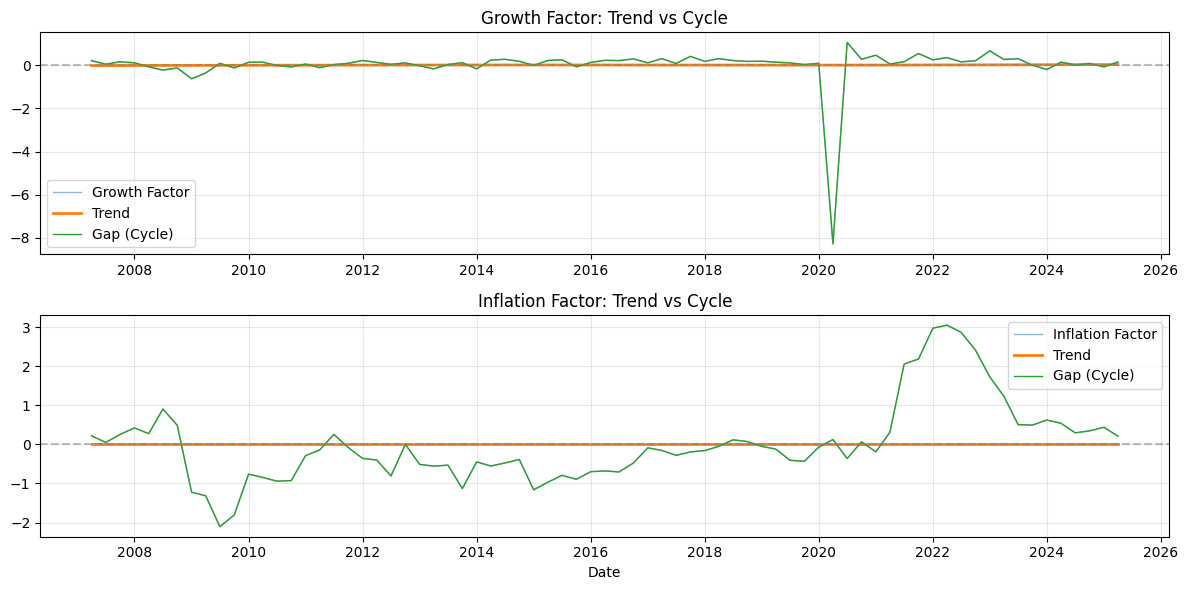

In [10]:
def hp_gap(series, demean=False):
    """Apply HP filter to extract cycle and trend."""
    m = estimation_mask(series.index)
    if demean:
        # For flat trend: gap = inflation factor - zero = demeaned inflation factor
        gap = series - series[m].mean()
        gap = _standardize(gap, m)   # scale on non-COVID months
        gap.name = series.name + "_Gap"
        trend = pd.Series(0, index=series.index, name=series.name + "_Trend")
    else:
        # Normal HP filter. NOTE the filter itself still runs on the full
        # series (it needs a contiguous sample), so the 2020 spike does perturb
        # the trend locally; only the cycle's SCALE is estimated ex-COVID.
        cycle, trend = hpfilter(series, lamb=HP_LAMBDA_M)
        gap = _standardize(cycle, m)
        gap.name = series.name + "_Gap"
        trend.name = series.name + "_Trend"
    
    return gap, trend

# Extract gaps and trends
# Growth: keep original (may have trend)
# Inflation: demean to get flat trend around zero
g_gap, g_trend = hp_gap(gf, demean=False)
p_gap, p_trend = hp_gap(pf, demean=True)

print("✓ HP filter applied")
print(f"  Growth gap: {g_gap.name}")
print(f"  Inflation gap: {p_gap.name}")

# Plot gaps vs trends
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(gf.index, gf.values, label="Growth Factor", alpha=0.5, linewidth=1)
ax1.plot(g_trend.index, g_trend.values, label="Trend", linewidth=2)
ax1.plot(g_gap.index, g_gap.values, label="Gap (Cycle)", linewidth=1)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.set_title("Growth Factor: Trend vs Cycle")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(pf.index, pf.values, label="Inflation Factor", alpha=0.5, linewidth=1)
ax2.plot(p_trend.index, p_trend.values, label="Trend", linewidth=2)
ax2.plot(p_gap.index, p_gap.values, label="Gap (Cycle)", linewidth=1)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.set_title("Inflation Factor: Trend vs Cycle")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Classify Deterministic Quadrant Regimes

Quadrant Distribution:
Quadrant
Q1_LowG_LowPi      11
Q2_HighG_LowPi     32
Q3_HighG_HighPi    23
Q4_LowG_HighPi      7
Name: count, dtype: int64

Total observations: 73


C:\Users\james\AppData\Local\Temp\ipykernel_46892\2235660912.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return df.apply(lambda r: classify_quad(r[0], r[1]), axis=1).rename("Quadrant")


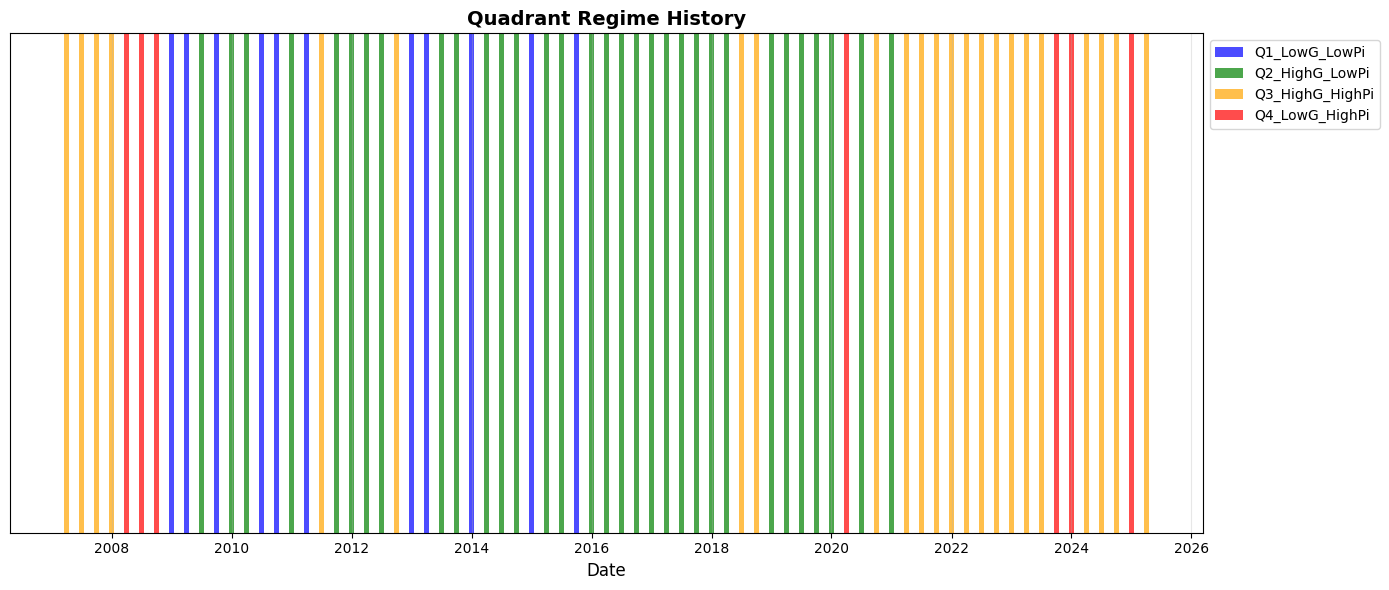


QUADRANT REGIMES - LAST 8 QUARTERS

Quarter      Month           Regime               Economic State 
--------------------------------------------------------------------------------
Q3 2023      July 2023       Q3_HighG_HighPi      Overheating    
Q4 2023      October 2023    Q4_LowG_HighPi       Stagflation    
Q1 2024      January 2024    Q4_LowG_HighPi       Stagflation    
Q2 2024      April 2024      Q3_HighG_HighPi      Overheating    
Q3 2024      July 2024       Q3_HighG_HighPi      Overheating    
Q4 2024      October 2024    Q3_HighG_HighPi      Overheating    
Q1 2025      January 2025    Q4_LowG_HighPi       Stagflation    
Q2 2025      April 2025      Q3_HighG_HighPi      Overheating    


In [11]:
def classify_quad(g, pi, tg=THETA_G, tpi=THETA_PI):
    """Memoryless quadrant classification (retained for comparison)."""
    if g < -tg and pi < -tpi: return "Q1_LowG_LowPi"
    if g > tg and pi < -tpi:  return "Q2_HighG_LowPi"
    if g > tg and pi >  tpi:  return "Q3_HighG_HighPi"
    if g < -tg and pi > tpi:  return "Q4_LowG_HighPi"
    return "Neutral"


# Trigger/duration logic lives in regime_core.py (shared with the UI).
# Aliased to the old private names so downstream cells need no edits.
from regime_core import (
    hysteretic_sign as _hysteretic_sign,
    assign_quadrants,
    duration_stats as _duration_stats,
    QUAD_BY_SIGN as _QUAD_BY_SIGN,
)


# ---- sensitivity of persistence to the hysteresis band ---------------------
print("=" * 78)
print("HYSTERESIS SENSITIVITY  (theta = 0 reproduces the memoryless classifier)")
print("=" * 78)
print(f"\n{'theta':>7} {'avg duration':>14} {'switches':>10}   quadrant counts")
print("-" * 78)
for _th in [0.0, 0.10, 0.25, 0.50, 0.75, 1.00]:
    _q = assign_quadrants(g_gap, p_gap, theta=_th)
    _avg, _sw = _duration_stats(_q)
    _counts = _q.value_counts()
    _cstr = " ".join(f"{k.split('_')[0]}:{_counts.get(k, 0):>3}"
                     for k in ["Q1_LowG_LowPi", "Q2_HighG_LowPi",
                               "Q3_HighG_HighPi", "Q4_LowG_HighPi"])
    _mark = "  <-- selected" if abs(_th - HYSTERESIS_THETA) < 1e-9 else ""
    print(f"{_th:>7.2f} {_avg:>11.1f} mo {_sw:>10}   {_cstr}{_mark}")

# Assign quadrants at the configured band
quad = assign_quadrants(g_gap, p_gap, HYSTERESIS_THETA)
_avg, _sw = _duration_stats(quad)

print(f"\nUsing HYSTERESIS_THETA = {HYSTERESIS_THETA}")
print("\nQuadrant Distribution:")
print(quad.value_counts().sort_index())
print(f"\nTotal observations: {len(quad)}")
print(f"Average regime duration: {_avg:.1f} months  ({_sw} switches)")

# Plot regime history over time
fig, ax = plt.subplots(figsize=(14, 6))

# Create color mapping
colors_map = {
    "Q1_LowG_LowPi": "blue",
    "Q2_HighG_LowPi": "green",
    "Q3_HighG_HighPi": "orange",
    "Q4_LowG_HighPi": "red",
    "Neutral": "gray"
}

# Plot as bars (ensures no gaps)
colors = [colors_map[regime] for regime in quad.values]
ax.bar(quad.index, height=1, width=30, color=colors, alpha=0.7, align='center')

# Create legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, alpha=0.7, label=regime) 
                   for regime, color in colors_map.items() if regime in quad.values]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

ax.set_ylim(0, 1)
ax.set_xlabel("Date", fontsize=12)
ax.set_title("Quadrant Regime History", fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
ax.set_yticks([])
plt.tight_layout()
plt.show()

# Display last 8 quarters (2 years) in table format
print("\n" + "="*80)
print("QUADRANT REGIMES - LAST 8 QUARTERS")
print("="*80)

last_8_quarters = quad.tail(8)  # Get last 8 observations (quarterly data)

# Map regime codes to economic states
regime_names = {
    "Q1_LowG_LowPi": "Recession",
    "Q2_HighG_LowPi": "Goldilocks", 
    "Q3_HighG_HighPi": "Overheating",
    "Q4_LowG_HighPi": "Stagflation"
}

# Create detailed table
regime_table = pd.DataFrame({
    'Quarter': ['Q' + str((last_8_quarters.index[i].month - 1) // 3 + 1) + ' ' + str(last_8_quarters.index[i].year) 
                for i in range(len(last_8_quarters))],
    'Month': last_8_quarters.index.strftime('%B %Y'),
    'Regime': last_8_quarters.values,
    'Economic State': [regime_names.get(r, r) for r in last_8_quarters.values]
})

# Display formatted table
print(f"\n{'Quarter':<12} {'Month':<15} {'Regime':<20} {'Economic State':<15}")
print("-" * 80)
for _, row in regime_table.iterrows():
    print(f"{row['Quarter']:<12} {row['Month']:<15} {row['Regime']:<20} {row['Economic State']:<15}")

In [12]:
# Check data availability for 2025
print("="*70)
print("DATA AVAILABILITY CHECK - 2025")
print("="*70)

print("\nQuadrant Regimes (quad):")
print(f"  Latest date: {quad.index[-1].strftime('%Y-%m-%d')}")
print(f"  Total observations: {len(quad)}")
print(f"  2025 data points: {len(quad[quad.index.year == 2025])}")
if len(quad[quad.index.year == 2025]) > 0:
    print(f"  2025 months available: {[d.strftime('%Y-%m') for d in quad[quad.index.year == 2025].index]}")

print("\nGrowth Factor (gf):")
print(f"  Latest date: {gf.index[-1].strftime('%Y-%m-%d')}")
print(f"  2025 data points: {len(gf[gf.index.year == 2025])}")

print("\nInflation Factor (pf):")
print(f"  Latest date: {pf.index[-1].strftime('%Y-%m-%d')}")
print(f"  2025 data points: {len(pf[pf.index.year == 2025])}")

print("\n" + "="*70)
print("MISSING DATA SUMMARY")
print("="*70)
print(f"\nToday's date: {dt.date.today().strftime('%Y-%m-%d')}")
print(f"Current month: {dt.date.today().strftime('%Y-%m')}")
print(f"\nLast regime classification: {quad.index[-1].strftime('%Y-%m')}")

months_behind = (dt.date.today().year - quad.index[-1].year) * 12 + (dt.date.today().month - quad.index[-1].month)
print(f"Months behind current: {months_behind}")

missing_months_2025 = []
for m in range(1, dt.date.today().month + 1):
    check_date = pd.Timestamp(f"2025-{m:02d}-01")
    if check_date not in quad.index:
        missing_months_2025.append(f"2025-{m:02d}")

if missing_months_2025:
    print(f"\nMissing 2025 months: {', '.join(missing_months_2025)}")
else:
    print("\nNo missing 2025 months (all available data through current month)")

print("\nNote: FRED economic indicators typically have 1-2 month reporting lag")

DATA AVAILABILITY CHECK - 2025

Quadrant Regimes (quad):
  Latest date: 2025-04-01
  Total observations: 73
  2025 data points: 2
  2025 months available: ['2025-01', '2025-04']

Growth Factor (gf):
  Latest date: 2025-04-01
  2025 data points: 2

Inflation Factor (pf):
  Latest date: 2025-04-01
  2025 data points: 2

MISSING DATA SUMMARY

Today's date: 2025-11-16
Current month: 2025-11

Last regime classification: 2025-04
Months behind current: 7

Missing 2025 months: 2025-02, 2025-03, 2025-05, 2025-06, 2025-07, 2025-08, 2025-09, 2025-10, 2025-11

Note: FRED economic indicators typically have 1-2 month reporting lag


## 9. Fit Gaussian Mixture Model for Probabilistic Regimes

In [15]:
def gmm_regimes(g_gap, pi_gap, n_components=4):
    """Fit GMM to (growth gap, inflation gap) space."""
    df = pd.concat([g_gap, pi_gap], axis=1).dropna()
    X  = df.values

    # Fit on non-COVID months only, then classify EVERY month. Leaving 2020 in
    # spent a whole component on a single observation.
    m = estimation_mask(df.index).values
    gmm = GaussianMixture(n_components=n_components, covariance_type="full", random_state=42)
    gmm.fit(X[m])
    print(f"  GMM fit on {m.sum()} of {len(m)} months "
          f"({(~m).sum()} excluded as COVID), classifying all {len(m)}")

    labels = gmm.predict(X)
    probs  = gmm.predict_proba(X)

    labels = pd.Series(labels, index=df.index, name="GMM_Regime")
    probs  = pd.DataFrame(probs, index=df.index, 
                         columns=[f"Regime_{i}" for i in range(n_components)])

    return gmm, labels, probs

# Fit GMM
gmm, labels, probs = gmm_regimes(g_gap, p_gap)

print("GMM fitted with 4 components")
print(f"Converged: {gmm.converged_}")
print(f"\nRegime Distribution:")
print(labels.value_counts().sort_index())

# Display regime probabilities for last 8 quarters
print("\n" + "="*100)
print("REGIME PROBABILITIES - LAST 8 QUARTERS")
print("="*100)

last_8_indices = quad.tail(8).index
prob_table = pd.DataFrame({
    'Quarter': ['Q' + str((last_8_indices[i].month - 1) // 3 + 1) + ' ' + str(last_8_indices[i].year) 
                for i in range(len(last_8_indices))],
    'Month': last_8_indices.strftime('%b %Y'),
    'Quadrant (Sec 8)': quad.tail(8).values,
    'Regime 0': [f"{probs.loc[idx, 'Regime_0']:.1%}" for idx in last_8_indices],
    'Regime 1': [f"{probs.loc[idx, 'Regime_1']:.1%}" for idx in last_8_indices],
    'Regime 2': [f"{probs.loc[idx, 'Regime_2']:.1%}" for idx in last_8_indices],
    'Regime 3': [f"{probs.loc[idx, 'Regime_3']:.1%}" for idx in last_8_indices]
})

print(f"\n{'Quarter':<12} {'Month':<12} {'Quadrant (Sec 8)':<20} {'Regime 0':>10} {'Regime 1':>10} {'Regime 2':>10} {'Regime 3':>10}")
print("-" * 100)
for _, row in prob_table.iterrows():
    print(f"{row['Quarter']:<12} {row['Month']:<12} {row['Quadrant (Sec 8)']:<20} {row['Regime 0']:>10} {row['Regime 1']:>10} {row['Regime 2']:>10} {row['Regime 3']:>10}")

GMM fitted with 4 components
Converged: True

Regime Distribution:
GMM_Regime
0    19
1     8
2    45
3     1
Name: count, dtype: int64

REGIME PROBABILITIES - LAST 8 QUARTERS

Quarter      Month        Quadrant (Sec 8)       Regime 0   Regime 1   Regime 2   Regime 3
----------------------------------------------------------------------------------------------------
Q3 2023      Jul 2023     Q3_HighG_HighPi           16.3%       0.1%      83.6%       0.0%
Q4 2023      Oct 2023     Q4_LowG_HighPi            84.1%       0.0%      15.9%       0.0%
Q1 2024      Jan 2024     Q4_LowG_HighPi            98.5%       0.0%       1.5%       0.0%
Q2 2024      Apr 2024     Q3_HighG_HighPi           49.4%       0.0%      50.5%       0.0%
Q3 2024      Jul 2024     Q3_HighG_HighPi           73.4%       0.0%      26.6%       0.0%
Q4 2024      Oct 2024     Q3_HighG_HighPi           72.3%       0.0%      27.7%       0.0%
Q1 2025      Jan 2025     Q4_LowG_HighPi            89.9%       0.0%      10.1%      

## 10. Map GMM Regimes to Economic States

In [ ]:
# ===========================================================================
# GMM clusters are reported on their OWN terms, not forced into quadrants.
# ===========================================================================
# The GMM fits density structure in (growth gap, inflation gap) space, and that
# structure turns out to be roughly CONCENTRIC (a large "normal times" cluster
# near the origin, plus progressively more extreme shells) rather than
# quadrant-shaped. Mapping centroids through classify_quad() therefore produced
# a non-injective mapping -- two clusters both landing in "Overheating" while
# nothing landed in "Goldilocks" -- and a 213-observation cluster centred
# essentially AT the origin being labelled "Overheating" because the quadrant
# threshold is exactly zero.
#
# So:
#   * the DETERMINISTIC quadrants (Section 8) are the regime taxonomy
#   * the GMM is reported separately as a data-driven robustness check, with
#     descriptive names derived from where its centroids actually sit
#   * the two are connected by an empirical P(quadrant | cluster) profile,
#     which is what supplies soft quadrant probabilities downstream

def _describe_level(v, lo=-0.75, hi=0.75, deep=2.0):
    """Readable bucket for a standardized centroid coordinate."""
    if v <= -deep: return "DeepLow"
    if v <= lo:    return "Low"
    if v <   hi:   return "Mid"
    return "High"


def name_gmm_clusters(g_gap, pi_gap, labels):
    """Descriptive name per GMM cluster, based on its centroid position."""
    df = pd.concat([g_gap, pi_gap, labels], axis=1).dropna()
    names = {}
    for k in sorted(df["GMM_Regime"].unique()):
        sub_k = df[df["GMM_Regime"] == k]
        mg  = sub_k[g_gap.name].mean()
        mpi = sub_k[pi_gap.name].mean()
        names[k] = f"C{k}_{_describe_level(mg)}G_{_describe_level(mpi)}Pi"
    return names


def gmm_quadrant_profile(labels, quad_series):
    """
    Empirical P(quadrant | cluster) as a (cluster x quadrant) matrix.

    This is the honest bridge between the two classifications: rather than
    asserting cluster k IS quadrant q, it records how cluster k's months
    actually distribute across quadrants. Downstream, soft quadrant
    probabilities follow by marginalization:

        P(quadrant q | t) = sum_k P(cluster k | t) * P(quadrant q | cluster k)
    """
    df = pd.concat([labels, quad_series], axis=1).dropna()
    prof = pd.crosstab(df[labels.name], df[quad_series.name], normalize="index")
    return prof


cluster_names   = name_gmm_clusters(g_gap, p_gap, labels)
econ_labels     = labels.map(cluster_names).rename("GMM_Cluster_Desc")
quadrant_profile = gmm_quadrant_profile(labels, quad)

print("=" * 78)
print("GMM CLUSTERS (reported on their own terms -- NOT mapped to quadrants)")
print("=" * 78)
print(f"\n{'Cluster':<22} {'Avg Growth':>11} {'Avg Infl':>10} {'N':>6}")
print("-" * 78)
_df = pd.concat([g_gap, p_gap, labels], axis=1).dropna()
for k in sorted(cluster_names):
    s = _df[_df["GMM_Regime"] == k]
    print(f"{cluster_names[k]:<22} {s[g_gap.name].mean():>11.3f} "
          f"{s[p_gap.name].mean():>10.3f} {len(s):>6}")

print("\n" + "=" * 78)
print("P(quadrant | cluster) -- empirical bridge to the deterministic taxonomy")
print("=" * 78)
_pp = quadrant_profile.rename(index=cluster_names)
print("\n" + _pp.to_string(float_format=lambda x: f"{x:6.1%}"))

print("\nRow sums (must be 1.0):",
      ", ".join(f"{v:.3f}" for v in quadrant_profile.sum(axis=1)))
print(f"\nDeterministic quadrant distribution (the regime taxonomy):")
print(quad.value_counts().sort_index().to_string())

## 11. Download ETF Price Data and Calculate Returns

In [52]:
def download_prices(tickers, start="1995-01-01"):
    """Download ETF prices from Yahoo Finance."""
    raw_data = yf.download(list(tickers.keys()), start=start, progress=False, auto_adjust=True)
    # yfinance with auto_adjust=True returns Close instead of Adj Close
    if isinstance(raw_data.columns, pd.MultiIndex):
        # Multiple tickers: columns are MultiIndex (Price Type, Ticker)
        data = raw_data.xs('Close', level=0, axis=1)
    else:
        # Single ticker
        data = raw_data[['Close']]
        data.columns = [list(tickers.keys())[0]]
    data.columns = list(tickers.values())
    return data


def quarterly_returns(prices):
    """Calculate quarterly returns."""
    # Resample to quarter-end, then calculate returns
    quarterly_prices = prices.resample("QE").last()   # QE = quarter-end ("Q" is deprecated)
    # Don't drop NaN - let individual assets have different start dates
    return quarterly_prices.pct_change()

# Download prices
print("Downloading ETF prices from Yahoo Finance...")
prices = download_prices(YAHOO_TICKERS, start="1995-01-01")
print(f"✓ Downloaded {prices.shape[1]} ETFs")
print(f"  Date range: {prices.index[0]} to {prices.index[-1]}")

# Calculate quarterly returns
returns = quarterly_returns(prices)
print(f"\n✓ Quarterly returns calculated: {returns.shape}")
print(f"  First non-null date for each asset:")
for col in returns.columns:
    first_valid = returns[col].first_valid_index()
    print(f"    {col}: {first_valid}")

# Preview
print("\n--- Latest Returns ---")
display(returns.tail())

✓ Downloaded 8 ETFs
  Date range: 1995-01-03 00:00:00 to 2025-11-14 00:00:00

✓ Quarterly returns calculated: (124, 8)
  First non-null date for each asset:
    Equity_US: 2003-12-31 00:00:00
    Equity_DevelopedExUS: 2003-09-30 00:00:00
    Equity_EM: 2005-03-31 00:00:00
    US_Aggregate_Bonds: 2015-03-31 00:00:00
    REITs: 1995-06-30 00:00:00
    Gold: 2004-03-31 00:00:00
    Commodities: 2007-12-31 00:00:00
    TIPS: 2004-12-31 00:00:00

--- Latest Returns ---
✓ Downloaded 8 ETFs
  Date range: 1995-01-03 00:00:00 to 2025-11-14 00:00:00

✓ Quarterly returns calculated: (124, 8)
  First non-null date for each asset:
    Equity_US: 2003-12-31 00:00:00
    Equity_DevelopedExUS: 2003-09-30 00:00:00
    Equity_EM: 2005-03-31 00:00:00
    US_Aggregate_Bonds: 2015-03-31 00:00:00
    REITs: 1995-06-30 00:00:00
    Gold: 2004-03-31 00:00:00
    Commodities: 2007-12-31 00:00:00
    TIPS: 2004-12-31 00:00:00

--- Latest Returns ---


C:\Users\james\AppData\Local\Temp\ipykernel_46892\4092114330.py:19: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_prices = prices.resample("Q").last()


,Equity_US,Equity_DevelopedExUS,Equity_EM,US_Aggregate_Bonds,REITs,Gold,Commodities,TIPS
Date,,,,,,,,
2024-12-31,-0.031048,-0.072699,-0.003826,0.011047,0.024910,-0.030492,-0.080922,-0.076762
2025-03-31,0.027379,0.044955,0.190022,0.049269,-0.042669,0.042609,0.067859,0.026831
2025-06-30,0.012743,0.114584,0.057923,-0.043287,0.107772,0.004269,0.130502,-0.006683
2025-09-30,0.020604,0.106965,0.166125,0.029908,0.081212,0.020501,0.056078,0.036303
2025-12-31,0.004016,0.029213,0.057642,0.017126,0.008631,0.000794,0.023365,-0.020018


In [50]:
# Check ETF data availability
print("="*70)
print("ETF DATA AVAILABILITY")
print("="*70)
for ticker, name in YAHOO_TICKERS.items():
    if name in prices.columns:
        first_date = prices[name].first_valid_index()
        last_date = prices[name].last_valid_index()
        n_obs = prices[name].notna().sum()
        print(f"{ticker:6s} ({name:25s}): {first_date.strftime('%Y-%m-%d')} to {last_date.strftime('%Y-%m-%d')} ({n_obs} obs)")
    else:
        print(f"{ticker:6s} ({name:25s}): NOT FOUND in downloaded data")

ETF DATA AVAILABILITY
SPY    (Equity_US                ): 2003-09-29 to 2025-11-14 (5570 obs)
VEA    (Equity_DevelopedExUS     ): 2003-04-14 to 2025-11-14 (5686 obs)
EEM    (Equity_EM                ): 2004-11-18 to 2025-11-14 (5282 obs)
AGG    (US_Aggregate_Bonds       ): 2007-04-11 to 2025-11-14 (4682 obs)
HYG    (Corp_HY                  ): 2014-11-07 to 2025-11-14 (2772 obs)
VNQ    (REITs                    ): 1995-01-03 to 2025-11-14 (7771 obs)
GLD    (Gold                     ): 2003-12-05 to 2025-11-14 (5522 obs)
PDBC   (Commodities              ): 2007-07-26 to 2025-11-14 (4608 obs)
TIP    (TIPS                     ): 2004-09-29 to 2025-11-14 (5318 obs)


## 12. Align Returns with Regimes

In [53]:
# Combine all regime data
factors = pd.concat([gf, pf, g_gap, p_gap, g_trend, p_trend], axis=1)
regimes = pd.concat([quad, labels, econ_labels, probs], axis=1)

# Convert both returns and regimes to quarter-start for alignment
returns_aligned = returns.copy()
returns_aligned.index = returns_aligned.index.to_period('Q').to_timestamp()

regimes_aligned = regimes.copy()
regimes_aligned.index = regimes_aligned.index.to_period('Q').to_timestamp()

# Regimes are MONTHLY; mapping them onto quarter-start stamps puts three rows
# on the same timestamp. Keep the LAST month of each quarter -- that is the
# point-in-time regime an allocator would actually observe at quarter end, and
# it avoids the duplicate-index errors that .loc lookups hit downstream.
# (This was previously masked: the quarterly ULC series had silently forced the
#  whole regime panel to quarterly frequency, so the mapping was 1:1.)
_dupes = regimes_aligned.index.duplicated(keep='last').sum()
regimes_aligned = regimes_aligned[~regimes_aligned.index.duplicated(keep='last')]
if _dupes:
    print(f'Collapsed {_dupes} intra-quarter regime rows (kept last month of each quarter)')

# Align with returns
idx = returns_aligned.index.intersection(regimes_aligned.index)
rets = returns_aligned.loc[idx]
regs = regimes_aligned.loc[idx]

print(f"Aligned dataset: {len(idx)} quarters")
if len(idx) > 0:
    print(f"Date range: {idx[0]} to {idx[-1]}")
    print(f"\nAssets: {list(rets.columns)}")
    
    # Show regime distribution in aligned dataset
    print(f"\nRegime Distribution in Aligned Dataset:")
    print(regs["Quadrant"].value_counts().sort_index())
    
    # Diagnostic: Check what's limiting the alignment
    print("\n" + "="*70)
    print("ALIGNMENT DIAGNOSTICS")
    print("="*70)
    print(f"Returns range: {returns_aligned.index[0]} to {returns_aligned.index[-1]} ({len(returns_aligned)} quarters)")
    print(f"Regimes range: {regimes_aligned.index[0]} to {regimes_aligned.index[-1]} ({len(regimes_aligned)} quarters)")
    print(f"Aligned range: {idx[0]} to {idx[-1]} ({len(idx)} quarters)")
    
    # Check for missing data in returns for aligned dates
    print(f"\nMissing return data in aligned period:")
    for col in rets.columns:
        missing = rets[col].isna().sum()
        if missing > 0:
            print(f"  {col}: {missing} missing observations")
    
else:
    print("WARNING: No overlapping dates between returns and regimes!")
    print(f"Returns date range: {returns_aligned.index[0]} to {returns_aligned.index[-1]}")
    print(f"Regimes date range: {regimes_aligned.index[0]} to {regimes_aligned.index[-1]}")

Aligned dataset: 73 quarters
Date range: 2007-04-01 00:00:00 to 2025-04-01 00:00:00

Assets: ['Equity_US', 'Equity_DevelopedExUS', 'Equity_EM', 'US_Aggregate_Bonds', 'REITs', 'Gold', 'Commodities', 'TIPS']

Regime Distribution in Aligned Dataset:
GMM_Regime_Econ
Q2_HighG_LowPi     45
Q3_HighG_HighPi    27
Q4_LowG_HighPi      1
Name: count, dtype: int64

ALIGNMENT DIAGNOSTICS
Returns range: 1995-01-01 00:00:00 to 2025-10-01 00:00:00 (124 quarters)
Regimes range: 2007-04-01 00:00:00 to 2025-04-01 00:00:00 (73 quarters)
Aligned range: 2007-04-01 00:00:00 to 2025-04-01 00:00:00 (73 quarters)

Missing return data in aligned period:
  US_Aggregate_Bonds: 31 missing observations
  Commodities: 2 missing observations


## 13. Calculate Regime-Conditional Moments

In [54]:
def regime_moments(returns, regime_labels, freq="M"):
    """Calculate mean and covariance for each regime."""
    ann = {"M":12, "Q":4, "A":1}[freq]

    df = returns.join(regime_labels.rename("Regime")).dropna(subset=["Regime"])
    grouped = df.groupby("Regime")

    mean_dict, cov_dict, n_dict = {}, {}, {}

    for reg, sub in grouped:
        R = sub.drop(columns=["Regime"])
        if len(R) < 5: continue
        mean_dict[reg] = R.mean() * ann
        cov_dict[reg]  = R.cov() * ann
        n_dict[reg]    = len(R)

    return mean_dict, cov_dict, n_dict

# Calculate regime-conditional moments (quarterly data)
# Taxonomy = deterministic quadrants (see Section 10).
mean_dict, cov_dict, n_dict = regime_moments(rets, regs["Quadrant"], freq="Q")

print("="*90)
print("REGIME-CONDITIONAL STATISTICS - ALL REGIMES")
print("="*90)

# Define regime order for consistent display
regime_order = ["Q1_LowG_LowPi", "Q2_HighG_LowPi", "Q3_HighG_HighPi", "Q4_LowG_HighPi"]
available_regimes = [r for r in regime_order if r in mean_dict.keys()]

# Get all asset names
if available_regimes:
    all_assets = mean_dict[available_regimes[0]].index.tolist()
    
    # Display table header
    header = f"{'Asset':<25}"
    for reg in available_regimes:
        header += f" {reg[:15]:>17}"
    print(f"\n{header}")
    print("-" * 90)
    
    # Display returns for each asset across regimes
    for asset in all_assets:
        row = f"{asset:<25}"
        for reg in available_regimes:
            ret = mean_dict[reg][asset]
            row += f" {ret:>16.2%}"
        print(row)
    
    # Display regime observation counts
    print("-" * 90)
    obs_row = f"{'Observations':<25}"
    for reg in available_regimes:
        obs_row += f" {n_dict[reg]:>16}"
    print(obs_row)
    
    # Calculate and display regime volatilities
    print("\n" + "="*90)
    print("REGIME-CONDITIONAL VOLATILITIES (Annualized)")
    print("="*90)
    print(f"\n{header}")
    print("-" * 90)
    
    for asset in all_assets:
        row = f"{asset:<25}"
        for reg in available_regimes:
            vol = np.sqrt(cov_dict[reg].loc[asset, asset])
            row += f" {vol:>16.2%}"
        print(row)
    
    print("-" * 90)
    print(obs_row)
else:
    print("\nNo regime-conditional statistics available.")

REGIME-CONDITIONAL STATISTICS - ALL REGIMES

Asset                        Q2_HighG_LowPi   Q3_HighG_HighPi
------------------------------------------------------------------------------------------
Equity_US                            3.39%            2.19%
Equity_DevelopedExUS                10.09%           -4.15%
Equity_EM                            6.76%           12.70%
US_Aggregate_Bonds                  -6.15%           14.18%
REITs                               12.95%            6.43%
Gold                                 3.58%            2.88%
Commodities                          7.61%            0.20%
TIPS                                12.94%           -2.97%
------------------------------------------------------------------------------------------
Observations                            45               27

REGIME-CONDITIONAL VOLATILITIES (Annualized)

Asset                        Q2_HighG_LowPi   Q3_HighG_HighPi
--------------------------------------------------------------

## 14. Compute Probability-Weighted Expected Returns and Covariance

In [55]:
def prob_mu(mean_dict, probs):
    """Probability-weighted expected returns."""
    regs = [r for r in probs.index if r in mean_dict]
    return sum(probs[r] * mean_dict[r] for r in regs)


def prob_cov(cov_dict, mean_dict, probs):
    """Probability-weighted covariance matrix."""
    regs = [r for r in probs.index if (r in cov_dict and r in mean_dict)]
    mu   = sum(probs[r] * mean_dict[r] for r in regs)
    assets = mu.index

    Σ = np.zeros((len(assets), len(assets)))
    for r in regs:
        p = probs[r]
        μk = mean_dict[r].reindex(assets)
        Σk = cov_dict[r].reindex(index=assets, columns=assets)
        diff = (μk - mu).values.reshape(-1,1)
        Σ += p*(Σk.values + diff @ diff.T)

    return pd.DataFrame(Σ, index=assets, columns=assets)

# Use current regime (100% probability on most recent regime)
today = idx[-1]
econ_today = regs.loc[today, "Quadrant"]
regime_probs = pd.Series({reg: 1.0 if reg==econ_today else 0.0 for reg in mean_dict.keys()})

print(f"Current Date: {today.strftime('%Y-%m-%d')}")
print(f"Current Regime: {econ_today}")
print(f"\nRegime Probabilities:")
for reg, prob in regime_probs.items():
    print(f"  {reg}: {prob:.0%}")

# Calculate probability-weighted moments
mu_pw = prob_mu(mean_dict, regime_probs)
Σ_pw  = prob_cov(cov_dict, mean_dict, regime_probs)

print(f"\n✓ Probability-weighted moments calculated")

Current Date: 2025-04-01
Current Regime: Q3_HighG_HighPi

Regime Probabilities:
  Q2_HighG_LowPi: 0%
  Q3_HighG_HighPi: 100%

✓ Probability-weighted moments calculated


## 15. Construct Mean-Variance Optimal Portfolios

In [ ]:
import warnings


def normalize_weights(w_raw, objective):
    """
    Scale a raw MV solution to a fully-invested portfolio (weights sum to 1).

    The tangency (max-Sharpe) portfolio is w ~ inv(Sigma) @ (mu - rf). A
    fully-invested version exists only when that vector's elements sum to a
    POSITIVE number. If the sum is negative, dividing by it flips every sign
    and silently returns the MINIMUM-Sharpe portfolio on the same ray -- the
    exact opposite of what was asked for.

    Guard both degenerate cases loudly instead of returning a wrong answer:
      sum ~ 0  -> no fully-invested scaling exists at all
      sum < 0  -> normalize by |sum| so the sign of the risk premium is
                  preserved; weights then sum to -1, NOT 1, so the
                  "fully invested" reading does not hold. Reported as a warning.
    """
    s = w_raw.sum()

    if abs(s) < 1e-12:
        warnings.warn(
            f"[{objective}] Raw weights sum to ~0 ({s:.2e}); no fully-invested "
            "scaling exists. Falling back to L1 normalization -- treat the "
            "resulting weights and Sharpe ratio as unidentified.",
            RuntimeWarning, stacklevel=2,
        )
        denom = np.abs(w_raw).sum()
        return w_raw / denom if denom > 0 else w_raw

    if s < 0:
        warnings.warn(
            f"[{objective}] Raw weights sum to {s:.4f} < 0, so no fully-invested "
            "max-Sharpe portfolio exists (rf exceeds the return on the global "
            "minimum-variance portfolio, or Sigma is near-singular). Normalizing "
            "by |sum| to preserve the sign of the risk premium -- NOTE the "
            "returned weights sum to -1, not 1.",
            RuntimeWarning, stacklevel=2,
        )
        return w_raw / abs(s)

    return w_raw / s


def mv_opt(mu, Sigma, objective="max_sharpe", rf=0.0):
    """
    Mean-variance optimization (unconstrained; shorts allowed).
    - max_sharpe: Maximize Sharpe ratio
    - min_var: Minimum variance

    NOTE: Sigma is inverted with pinv. If Sigma is rank-deficient (fewer
    in-regime observations than assets) pinv returns a pseudo-solution with
    no warning, and the resulting weights/Sharpe are not identified. Check
    n_dict against the asset count before trusting these numbers.
    """
    Sig = Sigma.reindex(index=mu.index, columns=mu.index)
    n_obs_rank = np.linalg.matrix_rank(Sig.values)
    if n_obs_rank < len(mu):
        warnings.warn(
            f"[{objective}] Covariance matrix is rank {n_obs_rank} for "
            f"{len(mu)} assets -- weights are not identified.",
            RuntimeWarning, stacklevel=2,
        )

    inv = np.linalg.pinv(Sig.values)
    ones = np.ones((len(mu), 1))

    if objective == "max_sharpe":
        excess = (mu - rf).values.reshape(-1, 1)
        w = inv @ excess
    else:
        w = inv @ ones

    w = normalize_weights(w, objective)
    return pd.Series(w.flatten(), index=mu.index)

# Construct portfolios
w_max = mv_opt(mu_pw, Σ_pw, "max_sharpe")
w_min = mv_opt(mu_pw, Σ_pw, "min_var")

print("✓ Portfolios constructed")
print(f"  Max Sharpe weights sum: {w_max.sum():+.4f}")
print(f"  Min Var    weights sum: {w_min.sum():+.4f}")

## 16. Display Results

In [57]:
print("="*70)
print("PROBABILITY-WEIGHTED EXPECTED RETURNS (Annualized)")
print("="*70)
for asset, ret in mu_pw.items():
    print(f"{asset:30s}: {ret:7.2%}")

print("\n" + "="*70)
print("PROBABILITY-WEIGHTED VOLATILITIES (Annualized)")
print("="*70)
vols = np.sqrt(np.diag(Σ_pw))
for asset, vol in zip(Σ_pw.index, vols):
    print(f"{asset:30s}: {vol:7.2%}")

print("\n" + "="*70)
print("MAX SHARPE RATIO PORTFOLIO")
print("="*70)
for asset, weight in w_max.items():
    if abs(weight) > 0.001:  # Only show significant weights
        print(f"{asset:30s}: {weight:7.2%}")
print(f"{'Total':30s}: {w_max.sum():7.2%}")

# Calculate portfolio metrics
port_ret_max = (w_max * mu_pw).sum()
port_vol_max = np.sqrt(w_max @ Σ_pw @ w_max)
sharpe_max = port_ret_max / port_vol_max

print(f"\nExpected Return: {port_ret_max:6.2%}")
print(f"Volatility:      {port_vol_max:6.2%}")
print(f"Sharpe Ratio:    {sharpe_max:6.2f}")

print("\n" + "="*70)
print("MINIMUM VARIANCE PORTFOLIO")
print("="*70)
for asset, weight in w_min.items():
    if abs(weight) > 0.001:
        print(f"{asset:30s}: {weight:7.2%}")
print(f"{'Total':30s}: {w_min.sum():7.2%}")

port_ret_min = (w_min * mu_pw).sum()
port_vol_min = np.sqrt(w_min @ Σ_pw @ w_min)
sharpe_min = port_ret_min / port_vol_min

print(f"\nExpected Return: {port_ret_min:6.2%}")
print(f"Volatility:      {port_vol_min:6.2%}")
print(f"Sharpe Ratio:    {sharpe_min:6.2f}")

PROBABILITY-WEIGHTED EXPECTED RETURNS (Annualized)
Equity_US                     :   2.19%
Equity_DevelopedExUS          :  -4.15%
Equity_EM                     :  12.70%
US_Aggregate_Bonds            :  14.18%
REITs                         :   6.43%
Gold                          :   2.88%
Commodities                   :   0.20%
TIPS                          :  -2.97%

PROBABILITY-WEIGHTED VOLATILITIES (Annualized)
Equity_US                     :   6.53%
Equity_DevelopedExUS          :  23.54%
Equity_EM                     :  14.45%
US_Aggregate_Bonds            :  17.12%
REITs                         :  18.76%
Gold                          :   6.47%
Commodities                   :  21.07%
TIPS                          :  23.63%

MAX SHARPE RATIO PORTFOLIO
Equity_US                     : 102.29%
Equity_DevelopedExUS          :  -1.32%
Equity_EM                     :  87.75%
US_Aggregate_Bonds            :  42.93%
REITs                         : 120.15%
Gold                          : -

## 17. Visualize Growth-Inflation State Space

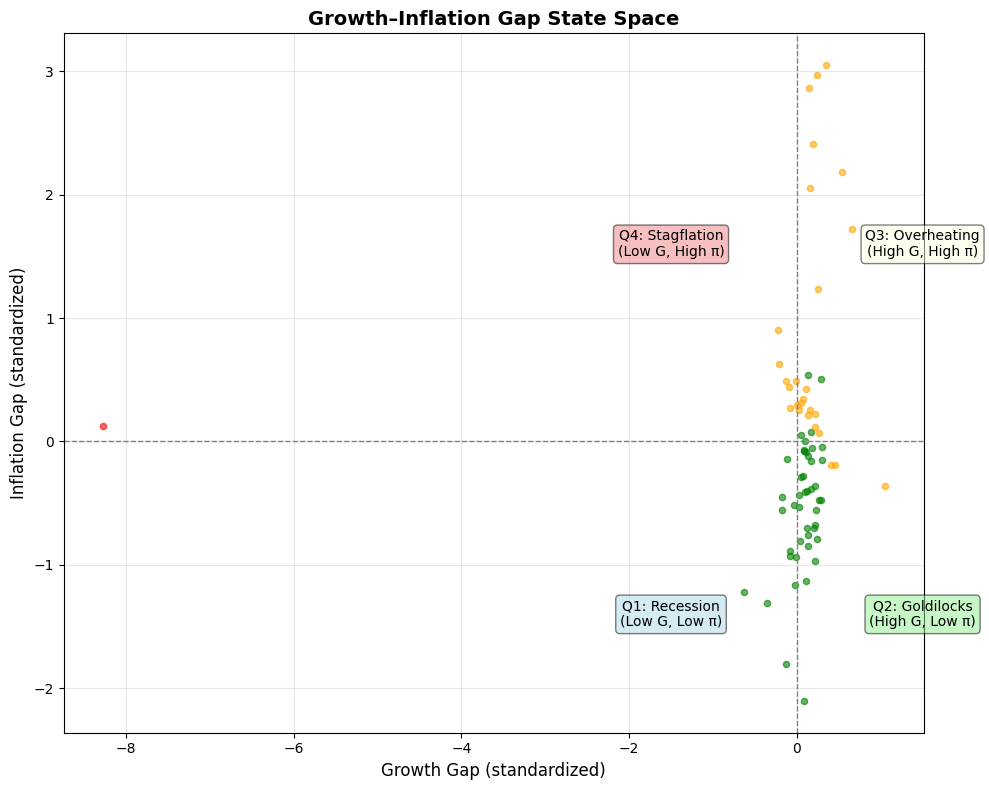

In [64]:
def plot_state_space(g_gap, pi_gap, regime_econ):
    """Plot growth-inflation state space colored by regime."""
    df = pd.concat([g_gap, pi_gap, regime_econ], axis=1).dropna()
    
    plt.figure(figsize=(10,8))
    
    colors = {
        "Q1_LowG_LowPi": "blue",
        "Q2_HighG_LowPi": "green", 
        "Q3_HighG_HighPi": "orange",
        "Q4_LowG_HighPi": "red",
        "Neutral": "gray"
    }
    
    for reg, sub in df.groupby(regime_econ.name):
        color = colors.get(reg, "black")
        plt.scatter(sub[g_gap.name], sub[pi_gap.name], 
                   label=reg, alpha=0.6, s=20, color=color)
    
    plt.axvline(0, ls="--", c="gray", linewidth=1)
    plt.axhline(0, ls="--", c="gray", linewidth=1)
    
    # Add quadrant labels
    plt.text(-1.5, -1.5, "Q1: Recession\n(Low G, Low π)", 
            fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    plt.text(1.5, -1.5, "Q2: Goldilocks\n(High G, Low π)", 
            fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    plt.text(1.5, 1.5, "Q3: Overheating\n(High G, High π)", 
            fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    plt.text(-1.5, 1.5, "Q4: Stagflation\n(Low G, High π)", 
            fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
    
    plt.title("Growth–Inflation Gap State Space", fontsize=14, fontweight='bold')
    plt.xlabel("Growth Gap (standardized)", fontsize=12)
    plt.ylabel("Inflation Gap (standardized)", fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot the state space
plot_state_space(factors["GrowthFactor_Gap"], factors["InflationFactor_Gap"], 
                regs["Quadrant"])

## 18. Plot Portfolio Weights

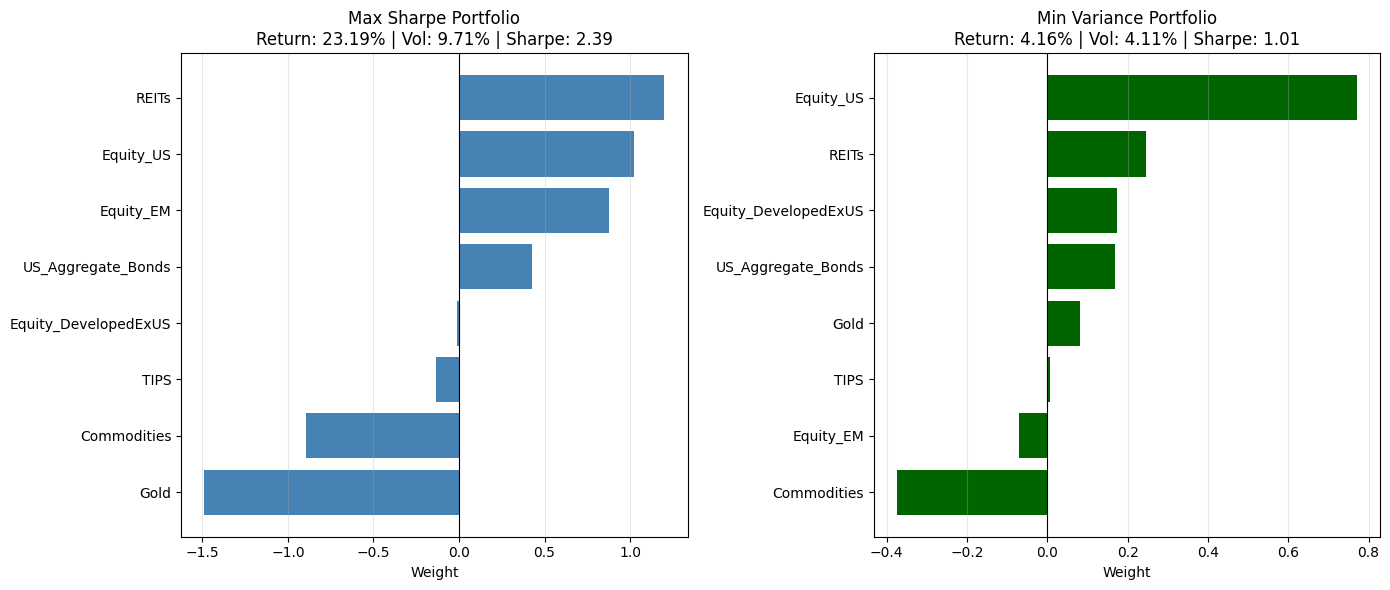

In [59]:
# Compare portfolio allocations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Max Sharpe portfolio
w_max_filtered = w_max[abs(w_max) > 0.001].sort_values()
ax1.barh(range(len(w_max_filtered)), w_max_filtered.values, color='steelblue')
ax1.set_yticks(range(len(w_max_filtered)))
ax1.set_yticklabels(w_max_filtered.index)
ax1.set_xlabel('Weight')
ax1.set_title(f'Max Sharpe Portfolio\nReturn: {port_ret_max:.2%} | Vol: {port_vol_max:.2%} | Sharpe: {sharpe_max:.2f}')
ax1.axvline(0, color='black', linewidth=0.8)
ax1.grid(alpha=0.3, axis='x')

# Min Variance portfolio
w_min_filtered = w_min[abs(w_min) > 0.001].sort_values()
ax2.barh(range(len(w_min_filtered)), w_min_filtered.values, color='darkgreen')
ax2.set_yticks(range(len(w_min_filtered)))
ax2.set_yticklabels(w_min_filtered.index)
ax2.set_xlabel('Weight')
ax2.set_title(f'Min Variance Portfolio\nReturn: {port_ret_min:.2%} | Vol: {port_vol_min:.2%} | Sharpe: {sharpe_min:.2f}')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Core Pipeline Summary (Sections 1-18)

The macro regime engine above has:

- Downloaded and transformed FRED macro data (WAGES ratio-linked back to 1964 via AHETPI; quarterly ULC excluded so the panel stays monthly)
- Extracted sign-pinned growth and inflation factors via PCA, with COVID months (2020-03 - 2020-12) excluded from estimation but still classified
- Classified four deterministic quadrant regimes with a causal hysteresis band (`HYSTERESIS_THETA`), with a sensitivity table in Section 8
- Fit a 4-component GMM, reported on its own terms and bridged to the quadrant taxonomy via an empirical P(quadrant | cluster) profile (Section 10)
- Aligned 11 ETF return series with the regime history and constructed regime-conditional mean-variance portfolios

Current-regime classification, regime distributions, and portfolio weights are printed by the cells above -- **numbers are deliberately not repeated here, so this summary cannot go stale.**

> **Everything in Sections 1-18 is estimated on the full sample** (standardization, PCA, two-sided HP filter, GMM, regime moments). These results are a *descriptive characterization* of regimes -- not achievable performance. For point-in-time (achievable) results and a decomposition of the look-ahead bias, see **Cells J-L** at the end of the notebook.

The empirical results section for the paper (Cells A-I) follows below.

## Display PCA Component Weights

In [21]:
print("="*70)
print("GROWTH FACTOR - PCA COMPONENT WEIGHTS")
print("="*70)
weights_growth = pd.Series(pca_g.components_[0], index=real_std.columns)
for indicator, weight in weights_growth.items():
    print(f"{indicator:20s}: {weight:7.4f}")
print(f"\nVariance Explained: {pca_g.explained_variance_ratio_[0]:.2%}")

print("\n" + "="*70)
print("INFLATION FACTOR - PCA COMPONENT WEIGHTS")
print("="*70)
weights_inflation = pd.Series(pca_p.components_[0], index=price_std.columns)
for indicator, weight in weights_inflation.items():
    print(f"{indicator:20s}: {weight:7.4f}")
print(f"\nVariance Explained: {pca_p.explained_variance_ratio_[0]:.2%}")

GROWTH FACTOR - PCA COMPONENT WEIGHTS
INDPRO              :  0.5414
PAYEMS              :  0.7151
UNRATE              : -0.2039
RETAIL              :  0.3447
HOUST               :  0.1876

Variance Explained: 76.24%

INFLATION FACTOR - PCA COMPONENT WEIGHTS
CPI                 :  0.5337
CPI_CORE            :  0.4907
PPI                 :  0.3970
WAGES               :  0.3600
ULC                 :  0.4327

Variance Explained: 62.11%


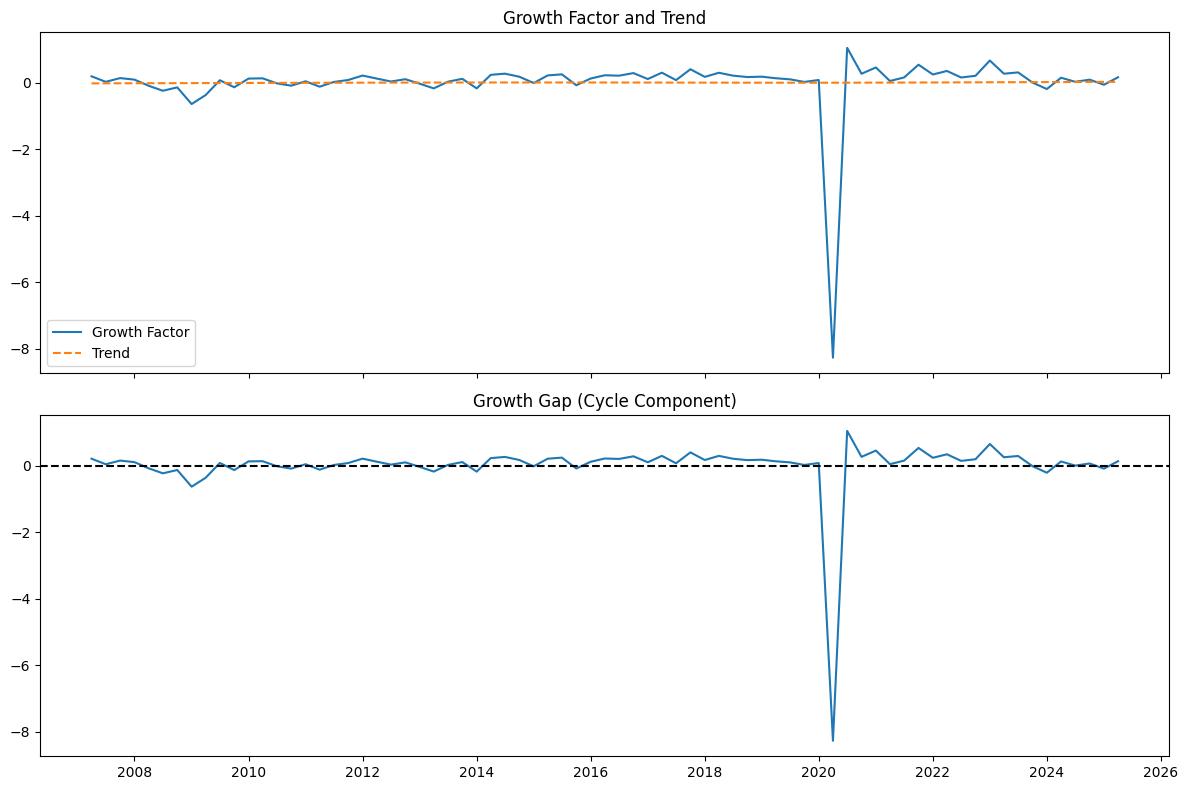

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(factors.index, factors["GrowthFactor"], label="Growth Factor")
axes[0].plot(factors.index, factors["GrowthFactor_Trend"], label="Trend", linestyle="--")
axes[0].set_title("Growth Factor and Trend")
axes[0].legend()

axes[1].plot(factors.index, factors["GrowthFactor_Gap"], label="Growth Gap")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Growth Gap (Cycle Component)")

plt.tight_layout()
plt.show()


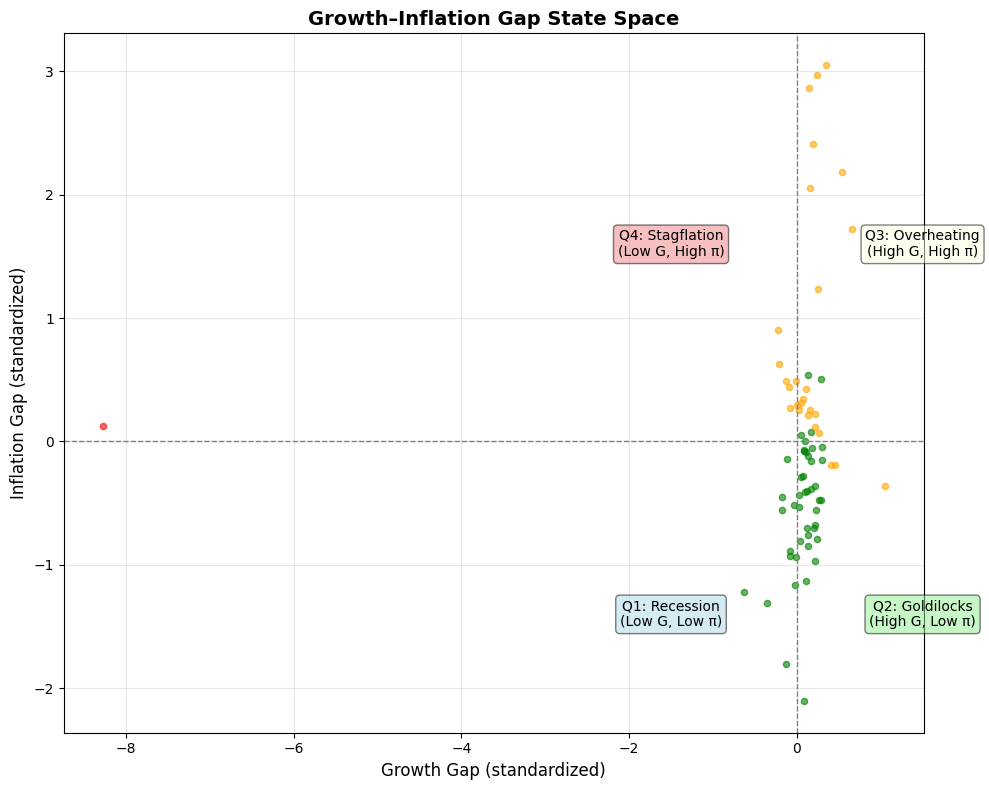

In [65]:
plot_state_space(
    factors["GrowthFactor_Gap"],
    factors["InflationFactor_Gap"],
    regimes["Quadrant"]
)

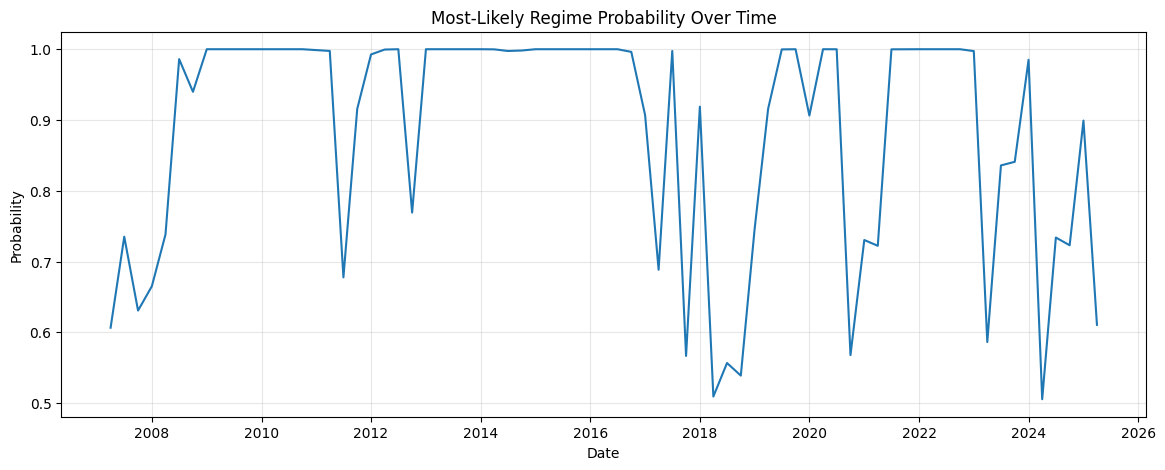

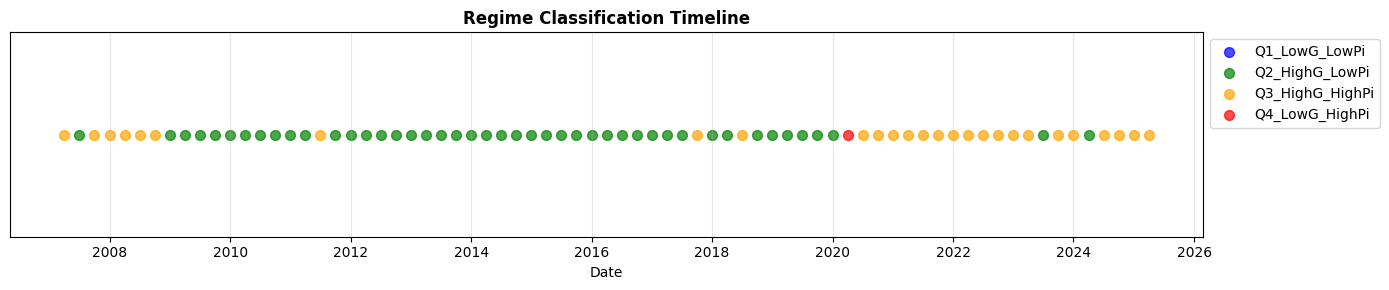

In [69]:
# Extract regime probabilities (select only Regime_0, Regime_1, etc. columns)
regime_probs = regimes[[col for col in regimes.columns if col.startswith("Regime_")]]

plt.figure(figsize=(14,5))
plt.plot(regime_probs.index, regime_probs.max(axis=1))
plt.title("Most-Likely Regime Probability Over Time")
plt.ylabel("Probability")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.show()

# Create regime color mapping
regime_colors = {
    "Q1_LowG_LowPi": "blue",
    "Q2_HighG_LowPi": "green",
    "Q3_HighG_HighPi": "orange",
    "Q4_LowG_HighPi": "red"
}

fig, ax = plt.subplots(figsize=(14, 3))
for regime, color in regime_colors.items():
    mask = regimes["Quadrant"] == regime
    ax.scatter(regimes.index[mask], [0]*mask.sum(), 
              c=color, s=50, alpha=0.7, label=regime)
ax.set_title("Regime Classification Timeline", fontsize=12, fontweight='bold')
ax.set_xlabel("Date")
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Empirical Results Section

Cells A-I build all tables, figures, and exports for the paper's empirical results section.

**Run in order after the existing pipeline has executed (cells 1-48).**

In [ ]:
# ============================================================
# CELL A - Monthly Returns + Alignment
# ============================================================

# Monthly log returns from daily prices (resample to month-end, then log diff)
monthly_prices = prices.resample("ME").last()
ret_m_raw = np.log(monthly_prices / monthly_prices.shift(1)).iloc[1:]

# Normalize all indices to month-start for alignment.
# This reconciles month-end price index with FRED's month-start index.
ret_m_raw.index = ret_m_raw.index.to_period("M").to_timestamp()

quad_m = quad.copy()
quad_m.index = quad_m.index.to_period("M").to_timestamp()

probs_m = probs.copy()
probs_m.index = probs_m.index.to_period("M").to_timestamp()

# Intersect on common dates across all three sources
common_idx = (ret_m_raw.index
              .intersection(quad_m.index)
              .intersection(probs_m.index))

ret_m   = ret_m_raw.loc[common_idx]   # monthly log returns (NaN ok for short-history)
reg_m   = quad_m.loc[common_idx]      # monthly deterministic quadrant label
probs_m = probs_m.loc[common_idx]     # monthly GMM probabilities

print(f"Monthly aligned dataset: {len(common_idx)} months")
print(f"Date range: {common_idx[0].strftime('%Y-%m')} to {common_idx[-1].strftime('%Y-%m')}")
print(f"\nAsset coverage (non-null months):")
for col in ret_m.columns:
    n = ret_m[col].notna().sum()
    first = ret_m[col].first_valid_index()
    first_str = first.strftime('%Y-%m') if first is not None else "N/A"
    print(f"  {col:30s}: {n:4d} months  (from {first_str})")


In [ ]:
# ============================================================
# CELL B - Remap Regime Labels to Paper Convention
# ============================================================
# Code quadrant ordering differs from the paper:
# Paper Q1=Goldilocks, Q2=Overheating, Q3=Stagflation, Q4=Recession

from regime_core import CODE_TO_PAPER, PAPER_DISPLAY, PAPER_COLORS, PAPER_ORDER

# Apply remap to monthly regime series
reg_m_paper = reg_m.map(CODE_TO_PAPER)

# Soft quadrant probabilities by MARGINALIZATION rather than by asserting a
# one-to-one cluster->quadrant map (which was non-injective and produced
# duplicate columns):
#
#     P(quadrant q | t) = sum_k P(cluster k | t) * P(quadrant q | cluster k)
#
# probs_m           is (T x K)  -- GMM posterior over clusters
# quadrant_profile  is (K x Q)  -- empirical P(quadrant | cluster), Cell 25
_prof = quadrant_profile.reindex(
    index=[int(c.split("_")[1]) for c in probs_m.columns]
).fillna(0.0)

probs_code = pd.DataFrame(
    probs_m.values @ _prof.values,
    index=probs_m.index,
    columns=_prof.columns,
)

# Now relabel the QUADRANT columns into paper convention. Unique by
# construction, because CODE_TO_PAPER is injective on quadrants.
probs_paper = probs_code.rename(columns=CODE_TO_PAPER)
probs_paper = probs_paper.reindex(columns=PAPER_ORDER).fillna(0.0)

assert probs_paper.columns.is_unique, "quadrant probability columns must be unique"
_rowsum = probs_paper.sum(axis=1)
assert np.allclose(_rowsum, 1.0, atol=1e-8), \
    f"quadrant probabilities must sum to 1 (min {_rowsum.min():.4f}, max {_rowsum.max():.4f})"

print("Regime label remap (code -> paper convention):")
for code_k, paper_k in CODE_TO_PAPER.items():
    display = PAPER_DISPLAY.get(paper_k, paper_k)
    print(f"  {code_k:25s} -> {display}")

print(f"\nprobs_paper columns: {probs_paper.columns.tolist()}")
print(f"\nRegime distribution (paper convention):")
dist = reg_m_paper.value_counts().reindex(PAPER_ORDER)
for reg, n in dist.items():
    pct = n / len(reg_m_paper)
    bar = '#' * int(pct * 40)
    print(f"  {PAPER_DISPLAY[reg][:35]:35s}: {n:4d} months ({pct:.1%})  {bar}")


In [ ]:
# ============================================================
# CELL C - Monthly Regime-Conditional Moments + Statistics
# ============================================================

def regime_moments_m(returns_df, regime_series):
    '''Compute annualized (x12) mean, cov, count per regime.
    Uses dropna(how=any) per subset so short-history assets
    (EEM, PDBC) do not contaminate covariance estimates.'''
    mean_d, cov_d, n_d = {}, {}, {}
    df = returns_df.join(regime_series.rename("Regime"))
    for reg, sub in df.groupby("Regime"):
        R = sub.drop(columns=["Regime"]).dropna(how="any")
        if len(R) < 5:
            continue
        mean_d[reg] = R.mean() * 12   # annualized expected return
        cov_d[reg]  = R.cov()  * 12   # annualized covariance matrix
        n_d[reg]    = len(R)
    return mean_d, cov_d, n_d


def regime_stats(regime_series):
    '''Compute % time and avg duration via consecutive-run decomposition.'''
    total = regime_series.notna().sum()
    stats = {}
    for reg in regime_series.dropna().unique():
        mask   = regime_series == reg
        groups = (mask != mask.shift()).cumsum()
        runs   = mask.groupby(groups).sum()
        true_runs = runs[runs > 0]
        stats[reg] = {
            "n_months":            int(mask.sum()),
            "pct_months":          float(mask.sum() / total),
            "avg_duration_months": float(true_runs.mean()) if len(true_runs) > 0 else 0.0,
        }
    return pd.DataFrame(stats).T


# Compute monthly moments using paper-convention labels
mean_dict_m, cov_dict_m, n_dict_m = regime_moments_m(ret_m, reg_m_paper)
regime_stat_df = regime_stats(reg_m_paper).reindex(PAPER_ORDER).dropna()

print("Monthly regime-conditional moments (annualized x12):")
print(f"  Regimes found: {list(mean_dict_m.keys())}")
print(f"\nRegime occupancy statistics:")
print(f"  {'Regime':<40} {'N':>5}  {'%Time':>7}  {'Avg Duration':>13}")
print("  " + "-" * 70)
for reg in PAPER_ORDER:
    if reg not in regime_stat_df.index:
        continue
    row = regime_stat_df.loc[reg]
    print(f"  {PAPER_DISPLAY[reg]:<40} {int(row['n_months']):>5}  "
          f"{row['pct_months']:>7.1%}  {row['avg_duration_months']:>10.1f} mo")

print(f"\nSample annualized mean returns - Q1_Goldilocks:")
if "Q1_Goldilocks" in mean_dict_m:
    for asset, ret in mean_dict_m["Q1_Goldilocks"].items():
        print(f"  {asset:30s}: {ret:+.2%}")


In [ ]:
# ============================================================
# CELL D - Table 1: Regime-Conditional Asset Returns
# ============================================================

asset_names = ret_m.columns.tolist()   # 8 friendly asset names

rows = []
for reg in PAPER_ORDER:
    if reg not in mean_dict_m:
        continue
    mu_r  = mean_dict_m[reg]
    # Safe vol extraction: index-aligned pd.Series from diagonal of cov matrix
    vol_r = pd.Series(np.sqrt(np.diag(cov_dict_m[reg].values)), index=mu_r.index)
    sh_r  = (mu_r / vol_r).fillna(np.nan)   # Sharpe ratio (rf = 0)
    pct   = regime_stat_df.loc[reg, "pct_months"]          if reg in regime_stat_df.index else np.nan
    dur   = regime_stat_df.loc[reg, "avg_duration_months"] if reg in regime_stat_df.index else np.nan
    n_obs = n_dict_m.get(reg, 0)

    for asset in asset_names:
        rows.append({
            "Regime":       reg,
            "Asset":        asset,
            "Ann_Return":   mu_r.get(asset, np.nan),
            "Ann_Vol":      vol_r.get(asset, np.nan),
            "Sharpe":       sh_r.get(asset, np.nan),
            "Pct_Months":   pct,
            "Avg_Duration": dur,
            "N_Obs":        n_obs,
        })

table1_long = pd.DataFrame(rows)

# Wide format: rows = assets, columns = (metric, regime) MultiIndex
table1 = table1_long.pivot_table(
    index="Asset",
    columns="Regime",
    values=["Ann_Return", "Ann_Vol", "Sharpe", "Pct_Months", "Avg_Duration", "N_Obs"]
)
table1 = table1.reindex(columns=PAPER_ORDER, level="Regime")
table1.index.name = "Asset"

print("=" * 95)
print("TABLE 1: REGIME-CONDITIONAL ASSET RETURNS (annualized)")
print("=" * 95)

ret_sub = table1["Ann_Return"].rename(columns={r: PAPER_DISPLAY[r][:20] for r in PAPER_ORDER})
print("\nAnnualized Returns:")
print(ret_sub.to_string(float_format=lambda x: f"{x:+.2%}" if not pd.isna(x) else "  N/A "))

sh_sub = table1["Sharpe"].rename(columns={r: PAPER_DISPLAY[r][:20] for r in PAPER_ORDER})
print("\nSharpe Ratios (rf=0):")
print(sh_sub.to_string(float_format=lambda x: f"{x:+.2f}" if not pd.isna(x) else "  N/A"))

vol_sub = table1["Ann_Vol"].rename(columns={r: PAPER_DISPLAY[r][:20] for r in PAPER_ORDER})
print("\nAnnualized Volatility:")
print(vol_sub.to_string(float_format=lambda x: f"{x:.2%}" if not pd.isna(x) else "  N/A"))

print("\n[Table 1 stored as `table1` - will export to Excel in Cell H]")


In [ ]:
# ============================================================
# CELL E - Table 2: Regime-Conditional Correlations
# ============================================================

corr_dict = {}

print("=" * 78)
print("TABLE 2: REGIME-CONDITIONAL CORRELATION MATRICES")
print("=" * 78)

for reg in PAPER_ORDER:
    if reg not in cov_dict_m:
        print(f"\n{PAPER_DISPLAY[reg]}: insufficient data - skipping")
        continue

    cov_r   = cov_dict_m[reg]
    vol_r   = np.sqrt(np.diag(cov_r.values))
    outer_v = np.outer(vol_r, vol_r)
    outer_v[outer_v == 0] = np.nan  # guard against zero-vol assets

    corr_r = pd.DataFrame(
        cov_r.values / outer_v,
        index=cov_r.index,
        columns=cov_r.columns
    )
    corr_dict[reg] = corr_r

    print(f"\n{chr(8212)*60}")
    print(f"{PAPER_DISPLAY[reg]}  (N = {n_dict_m.get(reg, 0)} months)")
    print(f"{chr(8212)*60}")

    # Spotlight: equity-bond correlation
    eq_col   = "Equity_US"
    bond_col = "US_Aggregate_Bonds"
    if eq_col in corr_r.index and bond_col in corr_r.index:
        eb = corr_r.loc[eq_col, bond_col]
        bar_len = int(abs(eb) * 25)
        bar_dir = ("+" * bar_len) if eb >= 0 else ("-" * bar_len)
        print(f"  Equity-Bond (SPY-AGG) correlation: {eb:+.3f}  |{bar_dir}")

    # Full correlation matrix
    print(corr_r.to_string(float_format=lambda x: f"{x:+.3f}" if not pd.isna(x) else "  N/A"))

print("\n[Correlation matrices stored as `corr_dict` - will export to Excel in Cell H]")


In [ ]:
# ============================================================
# CELL F - Probability-Weighted Moments Time Series (Figure)
# ============================================================
import matplotlib.patches as mpatches

# 60/40 weight vector aligned to the asset order in mean_dict_m
_asset_idx = list(mean_dict_m.values())[0].index   # consistent asset order
w_6040 = pd.Series(0.0, index=_asset_idx)
if "Equity_US" in w_6040.index:
    w_6040["Equity_US"] = 0.60
if "US_Aggregate_Bonds" in w_6040.index:
    w_6040["US_Aggregate_Bonds"] = 0.40
w_6040_arr = w_6040.values

# Pre-extract regime moment arrays (avoid re-indexing inside the time loop)
_regs_avail = [r for r in PAPER_ORDER if r in mean_dict_m]
mu_arrays  = {r: mean_dict_m[r].reindex(_asset_idx).fillna(0).values for r in _regs_avail}
cov_arrays = {
    r: cov_dict_m[r].reindex(index=_asset_idx, columns=_asset_idx).fillna(0).values
    for r in _regs_avail
}

n_assets = len(_asset_idx)
T        = len(probs_paper)
ts_index = probs_paper.index

mu_ts_6040    = np.zeros(T)
sigma_ts_6040 = np.zeros(T)

for t in range(T):
    row_t = probs_paper.iloc[t]
    p_t   = {r: float(row_t[r]) for r in _regs_avail if r in row_t.index}

    # Prob-weighted mean vector: mu_t = sum_k p_k * mu_k
    mu_t = sum(p_t[r] * mu_arrays[r] for r in p_t)

    # Prob-weighted covariance (law of total variance + variance of means):
    # Sigma_t = sum_k p_k * [Sigma_k + (mu_k - mu_t)(mu_k - mu_t)^T]
    Sigma_t = np.zeros((n_assets, n_assets))
    for r, p in p_t.items():
        diff    = (mu_arrays[r] - mu_t).reshape(-1, 1)
        Sigma_t += p * (cov_arrays[r] + diff @ diff.T)

    # Project onto 60/40 portfolio
    mu_ts_6040[t]    = float(w_6040_arr @ mu_t)
    var_t            = float(w_6040_arr @ Sigma_t @ w_6040_arr)
    sigma_ts_6040[t] = np.sqrt(max(var_t, 0.0))

mu_ts_6040    = pd.Series(mu_ts_6040,    index=ts_index, name="Expected_Return_6040")
sigma_ts_6040 = pd.Series(sigma_ts_6040, index=ts_index, name="Volatility_6040")


def _shade_recessions(ax, start, end):
    '''NBER recession shading via FRED USREC series (silent fallback).'''
    try:
        usrec = pdr.get_data_fred("USREC",
                                   start=str(start.date()),
                                   end=str(end.date()))
        usrec = usrec.resample("ME").last().ffill()
        usrec.index = usrec.index.to_period("M").to_timestamp()
        in_rec, rec_start = False, None
        for date, val in usrec["USREC"].items():
            if val == 1 and not in_rec:
                rec_start, in_rec = date, True
            elif val == 0 and in_rec:
                ax.axvspan(rec_start, date, color="gray",
                           alpha=0.18, zorder=0, linewidth=0)
                in_rec = False
        if in_rec:
            ax.axvspan(rec_start, usrec.index[-1], color="gray",
                       alpha=0.18, zorder=0, linewidth=0)
    except Exception:
        pass


def _shade_regimes(ax, reg_series):
    '''Color bands for each regime classification period.'''
    for reg in PAPER_ORDER:
        in_r, r_start = False, None
        for date, val in reg_series.items():
            if val == reg and not in_r:
                r_start, in_r = date, True
            elif val != reg and in_r:
                ax.axvspan(r_start, date, color=PAPER_COLORS[reg],
                           alpha=0.08, zorder=0, linewidth=0)
                in_r = False
        if in_r:
            ax.axvspan(r_start, reg_series.index[-1],
                       color=PAPER_COLORS[reg], alpha=0.08, zorder=0, linewidth=0)


# Two-panel figure: top = expected return, bottom = volatility
fig_ts, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig_ts.subplots_adjust(hspace=0.06)

_shade_recessions(ax1, ts_index[0], ts_index[-1])
_shade_recessions(ax2, ts_index[0], ts_index[-1])
_shade_regimes(ax1, reg_m_paper.reindex(ts_index))
_shade_regimes(ax2, reg_m_paper.reindex(ts_index))

ax1.plot(ts_index, mu_ts_6040 * 100, color="steelblue", linewidth=1.3, zorder=2)
ax1.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.6)
ax1.set_ylabel("Expected Return (%, ann.)", fontsize=11)
ax1.set_title(
    "Probability-Weighted 60/40 Portfolio: Expected Return & Volatility",
    fontsize=13, fontweight="bold"
)
ax1.grid(alpha=0.3, zorder=1)

ax2.plot(ts_index, sigma_ts_6040 * 100, color="firebrick", linewidth=1.3, zorder=2)
ax2.set_ylabel("Volatility (%, ann.)", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.grid(alpha=0.3, zorder=1)

legend_patches = [
    mpatches.Patch(color=PAPER_COLORS[r], alpha=0.6, label=PAPER_DISPLAY[r])
    for r in PAPER_ORDER
]
legend_patches.append(mpatches.Patch(color="gray", alpha=0.4, label="NBER Recession"))
ax1.legend(handles=legend_patches, loc="upper left", fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

print(f"\nCurrent ({ts_index[-1].strftime('%Y-%m')}) prob-weighted 60/40 metrics:")
print(f"  Expected Return (ann.): {mu_ts_6040.iloc[-1]:+.2%}")
print(f"  Volatility     (ann.): {sigma_ts_6040.iloc[-1]:.2%}")
sr_now = (mu_ts_6040.iloc[-1] / sigma_ts_6040.iloc[-1]
          if sigma_ts_6040.iloc[-1] > 0 else float("nan"))
print(f"  Sharpe Ratio         : {sr_now:.2f}")


In [ ]:
# ============================================================
# CELL G - Table 3: Regime-Aware Portfolio Construction
# ============================================================

def mv_analytical(mu_series, cov_df, objective="max_sharpe", rf=0.0):
    '''Analytical MV optimization via numpy pinv.
    Unconstrained (shorts allowed) per paper methodology.

    Delegates to mv_opt (Cell 36) so both optimizers share one
    normalization path -- previously these two diverged, and this one
    silently flipped the portfolio sign when the raw weights summed
    to a negative number.'''
    return mv_opt(mu_series, cov_df, objective=objective, rf=rf)


def portfolio_metrics(weights, mu_series, cov_df):
    '''Portfolio expected return, vol, and Sharpe (rf=0).'''
    assets = mu_series.index
    w  = weights.reindex(assets).fillna(0).values
    mu = mu_series.values
    S  = cov_df.reindex(index=assets, columns=assets).values
    ret    = float(w @ mu)
    var    = float(w @ S @ w)
    vol    = np.sqrt(max(var, 0.0))
    sharpe = ret / vol if vol > 1e-12 else float("nan")
    return ret, vol, sharpe


portfolio_rows = []

# Per-regime portfolios
for reg in PAPER_ORDER:
    if reg not in mean_dict_m:
        continue
    mu_r  = mean_dict_m[reg]
    cov_r = cov_dict_m[reg]
    for obj_name, obj_key in [("Max Sharpe", "max_sharpe"),
                               ("Min Variance", "min_var")]:
        w_vec            = mv_analytical(mu_r, cov_r, obj_key)
        ret, vol, sharpe = portfolio_metrics(w_vec, mu_r, cov_r)
        row = {"Regime": PAPER_DISPLAY[reg], "Objective": obj_name}
        row.update({a: round(float(w_vec.get(a, 0.0)), 4) for a in ret_m.columns})
        row.update({"Port_Return": ret, "Port_Vol": vol, "Port_Sharpe": sharpe})
        portfolio_rows.append(row)

# Probability-weighted portfolio (most recent month)
latest_date  = probs_paper.index[-1]
latest_probs = probs_paper.iloc[-1]

mu_pw_m = sum(
    float(latest_probs[r]) * mean_dict_m[r].reindex(_asset_idx).fillna(0)
    for r in PAPER_ORDER
    if r in mean_dict_m and r in latest_probs.index
)

cov_pw_arr = np.zeros((len(_asset_idx), len(_asset_idx)))
for r in PAPER_ORDER:
    if r not in mean_dict_m or r not in latest_probs.index:
        continue
    p  = float(latest_probs[r])
    Ck = cov_dict_m[r].reindex(index=mu_pw_m.index, columns=mu_pw_m.index).fillna(0).values
    d  = (mean_dict_m[r].reindex(mu_pw_m.index).fillna(0).values - mu_pw_m.values).reshape(-1,1)
    cov_pw_arr += p * (Ck + d @ d.T)

cov_pw_m = pd.DataFrame(cov_pw_arr, index=mu_pw_m.index, columns=mu_pw_m.index)

for obj_name, obj_key in [("Max Sharpe", "max_sharpe"), ("Min Variance", "min_var")]:
    w_vec            = mv_analytical(mu_pw_m, cov_pw_m, obj_key)
    ret, vol, sharpe = portfolio_metrics(w_vec, mu_pw_m, cov_pw_m)
    row = {"Regime": f"Prob-Weighted ({latest_date.strftime('%Y-%m')})",
           "Objective": obj_name}
    row.update({a: round(float(w_vec.get(a, 0.0)), 4) for a in ret_m.columns})
    row.update({"Port_Return": ret, "Port_Vol": vol, "Port_Sharpe": sharpe})
    portfolio_rows.append(row)

# Static 60/40 benchmark
w_ref = w_6040.reindex(mu_pw_m.index).fillna(0)
ret_ref, vol_ref, sr_ref = portfolio_metrics(w_ref, mu_pw_m, cov_pw_m)
row = {"Regime": "60/40 Benchmark", "Objective": "Static"}
row.update({a: round(float(w_ref.get(a, 0.0)), 4) for a in ret_m.columns})
row.update({"Port_Return": ret_ref, "Port_Vol": vol_ref, "Port_Sharpe": sr_ref})
portfolio_rows.append(row)

table3 = pd.DataFrame(portfolio_rows).set_index(["Regime", "Objective"])

print("=" * 85)
print("TABLE 3: REGIME-AWARE PORTFOLIO CONSTRUCTION")
print("=" * 85)
metrics_df = table3[["Port_Return", "Port_Vol", "Port_Sharpe"]].rename(columns={
    "Port_Return": "Ann. Return",
    "Port_Vol":    "Ann. Vol",
    "Port_Sharpe": "Sharpe",
})
print(metrics_df.to_string(
    float_format=lambda x: f"{x:.3f}" if not pd.isna(x) else "  N/A"
))

# Grouped bar chart: Max Sharpe weights by regime
ms_rows     = table3.xs("Max Sharpe", level="Objective")
weight_cols = ret_m.columns.tolist()
x     = np.arange(len(weight_cols))
width = 0.13

fig_portfolio, ax_p = plt.subplots(figsize=(16, 6))

for i, (reg_label, row_data) in enumerate(ms_rows.iterrows()):
    color_key = next(
        (k for k, v in PAPER_DISPLAY.items() if v == reg_label), None
    )
    color = PAPER_COLORS.get(color_key, "steelblue") if color_key else "steelblue"
    ax_p.bar(
        x + i * width,
        [row_data.get(a, 0.0) for a in weight_cols],
        width, label=reg_label, color=color, alpha=0.85, edgecolor="white"
    )

ax_p.set_xticks(x + width * (len(ms_rows) - 1) / 2)
ax_p.set_xticklabels(weight_cols, rotation=40, ha="right", fontsize=10)
ax_p.axhline(0, color="black", linewidth=0.7)
ax_p.set_ylabel("Portfolio Weight", fontsize=11)
ax_p.set_title("Max Sharpe Portfolio Weights by Regime",
               fontsize=13, fontweight="bold")
ax_p.legend(fontsize=9, loc="upper right")
ax_p.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\n[Table 3 stored as `table3` - will export to Excel in Cell H]")


In [ ]:
# ============================================================
# CELL H - Export: Excel (all tables) + PNG (all figures)
# ============================================================
import os
from openpyxl.styles import Font, PatternFill, Alignment

OUTPUT_DIR = os.getcwd()
EXCEL_PATH = os.path.join(OUTPUT_DIR, "macro_regime_results.xlsx")

HDR_FILL  = PatternFill("solid", fgColor="2F5496")
HDR_FONT  = Font(bold=True, color="FFFFFF")
HDR_ALIGN = Alignment(horizontal="center", wrap_text=True)


def _style_sheet(ws):
    '''Bold blue header row + auto column widths + number formats.'''
    for cell in ws[1]:
        cell.font      = HDR_FONT
        cell.fill      = HDR_FILL
        cell.alignment = HDR_ALIGN
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            if not isinstance(cell.value, (int, float)):
                continue
            col_name = str(ws.cell(row=1, column=cell.column).value or "")
            if any(kw in col_name for kw in ("Return", "Vol", "Pct", "Weight")):
                cell.number_format = "0.00%"
            elif "Sharpe" in col_name or "Duration" in col_name:
                cell.number_format = "0.00"
            elif "N_Obs" in col_name:
                cell.number_format = "0"
            else:
                cell.number_format = "0.000"
    for col in ws.columns:
        lengths = [len(str(c.value or "")) for c in col]
        ws.column_dimensions[col[0].column_letter].width = (
            min(30, max(10, max(lengths) + 2))
        )


# Excel export
try:
    with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl") as writer:

        # Table 1 - flatten MultiIndex columns
        t1_flat = table1.copy()
        t1_flat.columns = [
            f"{metric}|{regime}" for metric, regime in t1_flat.columns
        ]
        t1_flat.to_excel(writer, sheet_name="Table1_RegimeReturns")
        _style_sheet(writer.sheets["Table1_RegimeReturns"])

        # Table 2 - one sheet per regime correlation matrix
        for reg in PAPER_ORDER:
            if reg not in corr_dict:
                continue
            sheet_name = f"T2_{reg}"[:31]   # Excel max 31 chars
            corr_dict[reg].to_excel(writer, sheet_name=sheet_name)
            _style_sheet(writer.sheets[sheet_name])

        # Table 3 - portfolio weights + metrics
        t3_export = table3.reset_index()
        t3_export.to_excel(writer, sheet_name="Table3_Portfolios", index=False)
        _style_sheet(writer.sheets["Table3_Portfolios"])

    print(f"Excel saved: {EXCEL_PATH}")
    print("  Sheets: Table1_RegimeReturns | T2_Q1..Q4 | Table3_Portfolios")

except PermissionError:
    print("ERROR: Close macro_regime_results.xlsx in Excel and re-run this cell.")

# PNG exports at 300 dpi
PNG_DPI = 300

# 1. State space (call existing function; grab gcf() before plt.show flushes)
plt.ioff()
plot_state_space(
    factors["GrowthFactor_Gap"],
    factors["InflationFactor_Gap"],
    regimes["Quadrant"]
)
fig_state = plt.gcf()
fig_state.savefig(
    os.path.join(OUTPUT_DIR, "state_space_regimes.png"),
    dpi=PNG_DPI, bbox_inches="tight"
)
plt.close(fig_state)
plt.ion()

# 2. Prob-weighted time series (fig_ts created in Cell F)
fig_ts.savefig(
    os.path.join(OUTPUT_DIR, "prob_weighted_6040_dynamics.png"),
    dpi=PNG_DPI, bbox_inches="tight"
)

# 3. Portfolio weights comparison (fig_portfolio created in Cell G)
fig_portfolio.savefig(
    os.path.join(OUTPUT_DIR, "portfolio_weights_comparison.png"),
    dpi=PNG_DPI, bbox_inches="tight"
)

print(f"\nPNGs saved at {PNG_DPI} dpi:")
for fname in [
    "state_space_regimes.png",
    "prob_weighted_6040_dynamics.png",
    "portfolio_weights_comparison.png",
]:
    fpath = os.path.join(OUTPUT_DIR, fname)
    tag   = "OK" if os.path.exists(fpath) else "MISSING"
    print(f"  [{tag}] {fpath}")


In [ ]:
# ============================================================
# CELL I - Empirical Results: Console Summary
# ============================================================
import os

DIV = "=" * 78

print(DIV)
print("  EMPIRICAL RESULTS SUMMARY - MACRO REGIME ANALYSIS")
print(DIV)

# 1. Equity-bond correlations per regime
print("\n1. EQUITY-BOND CORRELATIONS (SPY vs AGG)")
print("-" * 60)
for reg in PAPER_ORDER:
    if reg not in corr_dict:
        print(f"   {PAPER_DISPLAY[reg]}: insufficient data")
        continue
    corr_r   = corr_dict[reg]
    eq_col   = "Equity_US"
    bond_col = "US_Aggregate_Bonds"
    if eq_col in corr_r.index and bond_col in corr_r.index:
        eb_val  = corr_r.loc[eq_col, bond_col]
        bar_len = int(abs(eb_val) * 25)
        bar_dir = ("+" * bar_len) if eb_val >= 0 else ("-" * bar_len)
        print(f"   {PAPER_DISPLAY[reg]:<42}: {eb_val:+.3f}  |{bar_dir}")
    else:
        print(f"   {PAPER_DISPLAY[reg]:<42}: N/A")

# 2. Best and worst regime per asset
print(f"\n2. BEST / WORST REGIME PER ASSET (annualized return)")
print("-" * 78)
for asset in ret_m.columns:
    asset_rets = {
        r: float(mean_dict_m[r][asset])
        for r in PAPER_ORDER
        if r in mean_dict_m and asset in mean_dict_m[r].index
    }
    if not asset_rets:
        continue
    best  = max(asset_rets, key=asset_rets.get)
    worst = min(asset_rets, key=asset_rets.get)
    print(f"   {asset:30s}  "
          f"Best: {PAPER_DISPLAY[best][:15]:15s} ({asset_rets[best]:+.1%})  "
          f"Worst: {PAPER_DISPLAY[worst][:15]:15s} ({asset_rets[worst]:+.1%})")

# 3. Current regime probabilities
latest_date_str = probs_paper.index[-1].strftime('%Y-%m')
print(f"\n3. CURRENT REGIME PROBABILITIES  ({latest_date_str})")
print("-" * 60)
current_probs = probs_paper.iloc[-1].reindex(PAPER_ORDER)
dominant = current_probs.idxmax()
for reg in PAPER_ORDER:
    p    = float(current_probs[reg])
    bar  = "#" * int(p * 35)
    flag = "  <-- DOMINANT" if reg == dominant else ""
    print(f"   {PAPER_DISPLAY[reg]:<42}: {p:.1%}  {bar}{flag}")

# 4. Current prob-weighted 60/40 portfolio metrics
print(f"\n4. CURRENT PROB-WEIGHTED 60/40 PORTFOLIO  ({latest_date_str})")
print("-" * 60)
print(f"   Expected Return (ann.): {mu_ts_6040.iloc[-1]:+.2%}")
print(f"   Volatility     (ann.): {sigma_ts_6040.iloc[-1]:.2%}")
sr_cur = (mu_ts_6040.iloc[-1] / sigma_ts_6040.iloc[-1]
          if sigma_ts_6040.iloc[-1] > 0 else float("nan"))
print(f"   Sharpe Ratio         : {sr_cur:.2f}")

# 5. Regime occupancy statistics
print(f"\n5. REGIME OCCUPANCY STATISTICS (monthly frequency)")
print("-" * 60)
for reg in PAPER_ORDER:
    if reg not in regime_stat_df.index:
        continue
    row = regime_stat_df.loc[reg]
    print(f"   {PAPER_DISPLAY[reg]:<42}: "
          f"{row['pct_months']:.1%} of months, "
          f"avg {row['avg_duration_months']:.1f} month runs")

# 6. Output file locations
print(f"\n6. OUTPUT FILES")
print("-" * 60)
for fname in [
    "macro_regime_results.xlsx",
    "state_space_regimes.png",
    "prob_weighted_6040_dynamics.png",
    "portfolio_weights_comparison.png",
]:
    fpath = os.path.join(os.getcwd(), fname)
    tag   = "OK" if os.path.exists(fpath) else "NOT SAVED"
    print(f"   [{tag:8s}] {fpath}")

print(f"\n{DIV}")


## Point-in-Time (Real-Time) Analysis

Everything above is estimated on the **full sample**: standardization moments,
PCA loadings, the (two-sided) HP filter, and regime-conditional moments all see
the future. A 2005 regime label depends on 2025 data. Those results are a
valid *descriptive characterization*, but none of them are achievable.

Cells J-L rebuild the pipeline **point-in-time (PIT)**: for each month, the
entire chain (standardize -> PCA -> HP filter -> hysteretic quadrant) is
re-estimated on an expanding window ending at that month, and only the
endpoint estimate is kept. The HP endpoint of an expanding window is one-sided
by construction. A 1-month publication lag approximates FRED release timing.

- **Cell J** - PIT regime classification + agreement with full-sample labels
- **Cell K** - out-of-sample backtest with expanding regime moments
  (plus an oracle-labels variant that isolates label-revision bias)
- **Cell L** - look-ahead bias summary: in-sample vs achievable

Known limitations (stated, not solved): data revisions (first-print FRED
vintages are not used), no transaction costs, unconstrained weights under a
gross leverage cap, single sample path.

In [ ]:
# ============================================================
# CELL J - Point-in-Time Regime Classification
# ============================================================
# For each month m (after a burn-in), the full estimation chain is re-run on
# data through m ONLY, and the endpoint gap estimates are kept:
#
#     raw FRED -> transform_real / transform_prices   (window-masked moments)
#              -> extract_pc (sign-pinned)            (window-masked fit)
#              -> hp_gap                              (window-masked scaling)
#              -> endpoint value at m
#
# This reuses the SAME functions as the full-sample pipeline -- they were made
# mask-aware for the COVID exclusion, so an expanding window is just a shorter
# input. The hysteresis trigger then runs over the accumulated endpoint series,
# which is exactly the state machine a real-time allocator would have run
# (verified: trigger on a prefix == prefix of trigger on the full series).
#
# COVID months are excluded from each window's ESTIMATION moments, as in the
# full-sample pipeline. That rule is causal: the decision to treat 2020-03
# onward as an outlier window was makeable in 2020-03, not only in hindsight.

PIT_BURN_IN       = 120   # months of history before the first PIT estimate
PUBLICATION_LAG_M = 1     # macro month m treated as known at end of m+1

pit_idx_all = None

# Silence the per-window FutureWarnings etc. inside the loop; anything fatal
# still raises.
import warnings as _w

_g_end, _p_end = {}, {}
_months = real_raw.index.intersection(price_raw.index)

for _i in range(PIT_BURN_IN, len(_months)):
    _m = _months[_i]
    with _w.catch_warnings():
        _w.simplefilter("ignore")
        _rw = transform_real(real_raw.loc[:_m])
        _pw = transform_prices(price_raw.loc[:_m])
        if len(_rw) < PIT_BURN_IN - 24 or len(_pw) < PIT_BURN_IN - 24:
            continue
        _gf, _ = extract_pc(_rw, sign_ref="INDPRO")
        _pf, _ = extract_pc(_pw, sign_ref="CPI")
        _gf.name, _pf.name = "G", "P"
        _gg, _ = hp_gap(_gf, demean=False)
        _pg, _ = hp_gap(_pf, demean=True)
    _g_end[_m] = float(_gg.iloc[-1])
    _p_end[_m] = float(_pg.iloc[-1])

pit_g = pd.Series(_g_end, name="PIT_GrowthGap").sort_index()
pit_p = pd.Series(_p_end, name="PIT_InflationGap").sort_index()
pit_quad = assign_quadrants(pit_g, pit_p, HYSTERESIS_THETA)   # hysteresis at HYSTERESIS_THETA

print(f"PIT estimates: {len(pit_quad)} months, "
      f"{pit_quad.index[0].strftime('%Y-%m')} -> {pit_quad.index[-1].strftime('%Y-%m')}")
print(f"(each label for month m is available at end of month m+{PUBLICATION_LAG_M})")

# ---- how different is real time from hindsight? ----------------------------
_common = pit_quad.index.intersection(quad.index)
_agree  = (pit_quad.loc[_common] == quad.loc[_common])

print(f"\nGap-estimate correlation (PIT endpoint vs final two-sided):")
print(f"  growth   : {pit_g.loc[_common].corr(g_gap.loc[_common]):.3f}")
print(f"  inflation: {pit_p.loc[_common].corr(p_gap.loc[_common]):.3f}")

print(f"\nLabel agreement, PIT vs final: {_agree.mean():.1%} "
      f"of {len(_common)} months")

print("\nConfusion (rows = final full-sample label, cols = PIT label):")
_conf = pd.crosstab(quad.loc[_common], pit_quad.loc[_common])
print(_conf.to_string())

_dur_pit, _sw_pit = _duration_stats(pit_quad)
print(f"\nPIT regime duration: {_dur_pit:.1f} months ({_sw_pit} switches) "
      f"vs full-sample {_duration_stats(quad.loc[_common])[0]:.1f} months")

print("\nPIT quadrant distribution:")
print(pit_quad.value_counts().sort_index().to_string())

In [ ]:
# ============================================================
# CELL K - Out-of-Sample Backtest (expanding regime moments)
# ============================================================
# Timing, strictly causal at every step:
#   * decision at end of month d
#   * latest known regime state: pit_quad[d-1]   (1-month publication lag)
#   * moments: returns m <= d paired with states m <= d-1, expanding window
#   * weights earn the realized return of month d+1
#
# ORACLE variant: same loop, same expanding moments, but uses the FINAL
# full-sample labels (quad) instead of PIT labels. The oracle-minus-PIT gap
# isolates label-revision look-ahead; the in-sample-minus-oracle gap (Cell L)
# is moment-estimation look-ahead.

BACKTEST_START     = pd.Timestamp("2010-01-01")
MIN_REGIME_OBS     = 15    # else fall back to 60/40 for that month
GROSS_LEVERAGE_CAP = 3.0   # scale weights so sum|w| <= cap (residual in cash)

# Simple (not log) monthly returns: w . r is then exact portfolio arithmetic.
ret_bt = monthly_prices.pct_change()
ret_bt.index = ret_bt.index.to_period("M").to_timestamp()

_bt_counters = {"fallback_pit": 0, "fallback_oracle": 0, "negsum": 0, "rank": 0}


def _regime_weights(hist_ret, hist_lab, current, objective):
    """Expanding-window MV weights for the current regime, or None -> fallback."""
    lab = hist_lab.reindex(hist_ret.index)
    sub = hist_ret[lab == current].dropna(how="any")
    if len(sub) < MIN_REGIME_OBS:
        return None
    mu, S = sub.mean() * 12, sub.cov() * 12
    with warnings.catch_warnings(record=True) as _caught:
        warnings.simplefilter("always")
        w = mv_opt(mu, S, objective)
    for _c in _caught:
        _msg = str(_c.message)
        if "sum to" in _msg:  _bt_counters["negsum"] += 1
        elif "rank" in _msg:  _bt_counters["rank"]   += 1
    gross = w.abs().sum()
    if gross > GROSS_LEVERAGE_CAP:
        w = w * (GROSS_LEVERAGE_CAP / gross)
    return w


_w6040 = pd.Series(0.0, index=ret_bt.columns)
_w6040["Equity_US"], _w6040["US_Aggregate_Bonds"] = 0.60, 0.40
_wEQ = pd.Series(1.0 / ret_bt.shape[1], index=ret_bt.columns)

_bt = {k: {} for k in ["PIT_MaxSharpe", "PIT_MinVar", "Oracle_MaxSharpe",
                        "Static_6040", "EqualWeight"]}

def _last_label(lab_series, ts):
    """Latest label at or before ts. The macro panel has occasional missing
    months (a source series gap drops that month from the aligned index), and
    the honest behaviour is to keep acting on the last state actually known."""
    window = lab_series.loc[:ts]
    return window.iloc[-1] if len(window) else None

_bt_months = [m for m in ret_bt.index
              if m >= BACKTEST_START
              and len(pit_quad.loc[:m - pd.DateOffset(months=2)]) > 0]

for _r in _bt_months:                       # _r = month whose return we earn
    _d    = _r - pd.DateOffset(months=1)    # decision date (end of month _d)
    _know = _d - pd.DateOffset(months=PUBLICATION_LAG_M)  # latest known state
    _row  = ret_bt.loc[_r]
    if _row.isna().any():
        continue

    _hist_ret = ret_bt.loc[:_d]
    _hist_pit = pit_quad.loc[:_know]
    _hist_fin = quad.loc[:_know]

    for _name, _labs, _cur, _obj, _fb_key in [
        ("PIT_MaxSharpe",    _hist_pit, _last_label(pit_quad, _know), "max_sharpe", "fallback_pit"),
        ("PIT_MinVar",       _hist_pit, _last_label(pit_quad, _know), "min_var",    "fallback_pit"),
        ("Oracle_MaxSharpe", _hist_fin, _last_label(quad, _know),     "max_sharpe", "fallback_oracle"),
    ]:
        _w_vec = _regime_weights(_hist_ret, _labs, _cur, _obj)
        if _w_vec is None:
            _bt_counters[_fb_key] += 1
            _w_vec = _w6040
        _bt[_name][_r] = float(_w_vec.reindex(_row.index).fillna(0) @ _row)

    _bt["Static_6040"][_r] = float(_w6040 @ _row)
    _bt["EqualWeight"][_r] = float(_wEQ @ _row)

bt_returns = pd.DataFrame(_bt).sort_index()

# ---- performance metrics ---------------------------------------------------
def _perf(r):
    ann_ret = r.mean() * 12
    ann_vol = r.std(ddof=0) * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    wealth  = (1 + r).cumprod()
    max_dd  = (wealth / wealth.cummax() - 1).min()
    return pd.Series({"Ann_Return": ann_ret, "Ann_Vol": ann_vol,
                      "Sharpe": sharpe, "Max_Drawdown": max_dd})

bt_perf = bt_returns.apply(_perf).T

print("=" * 78)
print(f"OUT-OF-SAMPLE BACKTEST  ({bt_returns.index[0].strftime('%Y-%m')} -> "
      f"{bt_returns.index[-1].strftime('%Y-%m')}, {len(bt_returns)} months)")
print("=" * 78)
print(bt_perf.to_string(float_format=lambda x: f"{x:+.3f}"))
print(f"\nFallbacks to 60/40 (regime history < {MIN_REGIME_OBS} obs): "
      f"PIT {_bt_counters['fallback_pit']} strategy-months, "
      f"oracle {_bt_counters['fallback_oracle']}")
print(f"Optimizer warnings caught: negative-sum {_bt_counters['negsum']}, "
      f"rank-deficient {_bt_counters['rank']}")

# ---- cumulative wealth -----------------------------------------------------
fig_bt, ax_bt = plt.subplots(figsize=(14, 6))
_wealth = (1 + bt_returns).cumprod()
for _col in _wealth.columns:
    _lw = 2.0 if _col.startswith("PIT") else 1.2
    ax_bt.plot(_wealth.index, _wealth[_col], label=_col, linewidth=_lw)
ax_bt.set_yscale("log")
ax_bt.set_ylabel("Cumulative wealth (log scale)")
ax_bt.set_title("Out-of-Sample Cumulative Wealth: PIT Regime Strategies vs Benchmarks",
                fontsize=13, fontweight="bold")
ax_bt.legend(fontsize=9)
ax_bt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL L - Look-Ahead Bias: In-Sample vs Achievable
# ============================================================

print("=" * 78)
print("LOOK-AHEAD BIAS DECOMPOSITION")
print("=" * 78)

# In-sample reference: prob-weighted max-Sharpe Sharpe from Table 3
_t3 = table3.reset_index()
_is_row = _t3[_t3["Regime"].str.startswith("Prob-Weighted")
              & (_t3["Objective"] == "Max Sharpe")]
_is_sharpe = float(_is_row["Port_Sharpe"].iloc[0]) if len(_is_row) else float("nan")

_oracle_sharpe = bt_perf.loc["Oracle_MaxSharpe", "Sharpe"]
_pit_sharpe    = bt_perf.loc["PIT_MaxSharpe",    "Sharpe"]
_b6040_sharpe  = bt_perf.loc["Static_6040",      "Sharpe"]

print(f"""
Sharpe ratio of the max-Sharpe strategy, by information set:

  In-sample (Table 3: full-sample labels AND moments) : {_is_sharpe:+.2f}
  Oracle labels, expanding moments (OOS)              : {_oracle_sharpe:+.2f}
  Point-in-time labels AND moments (OOS, achievable)  : {_pit_sharpe:+.2f}
  Static 60/40 benchmark (OOS)                        : {_b6040_sharpe:+.2f}

Decomposition of the in-sample illusion:
  moment look-ahead (in-sample minus oracle) : {_is_sharpe - _oracle_sharpe:+.2f}
  label look-ahead  (oracle minus PIT)       : {_oracle_sharpe - _pit_sharpe:+.2f}
  total             (in-sample minus PIT)    : {_is_sharpe - _pit_sharpe:+.2f}
""")

print("The PIT row is the only number in this notebook that an investor could")
print("have earned. Everything above it in Tables 1-3 is a DESCRIPTIVE,")
print("full-sample characterization of regimes and should be presented as such.")

print("""
Remaining limitations of even the PIT track (stated, not solved):
  * FRED revisions: current-vintage data, not first prints (no ALFRED)
  * no transaction costs, despite monthly re-optimization
  * unconstrained MV weights under a gross-leverage cap of {cap:.0f}x
  * one sample path; no parameter uncertainty on theta, lambda, burn-in
""".format(cap=GROSS_LEVERAGE_CAP))